In [1]:
# Cell 1 — Final Stage 4 setup

import numpy as np
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
REPORTS_DIR = PROJECT_ROOT / "reports"

PICS_PATH = "https://physionet.org/files/picsdb/1.0.0/"

INFANTS = list(range(1, 11))

PRECURSOR_WINDOW = 15.0
FEATURE_WINDOW = 5.0
FEATURE_STEP = 1.0

RISK_NORMAL = 0
RISK_PRECURSOR = 1

print("=" * 70)
print("STAGE 4 — FINAL PRECURSOR RISK DATASET")
print("=" * 70)

print()
print("Project root:", PROJECT_ROOT)
print("Reports directory:", REPORTS_DIR)
print("Infants:", INFANTS)

print()
print("Precursor window:", PRECURSOR_WINDOW, "seconds")
print("Feature window:", FEATURE_WINDOW, "seconds")
print("Feature step:", FEATURE_STEP, "seconds")

print()
print("Risk labels:", RISK_NORMAL, "= Normal,", RISK_PRECURSOR, "= Precursor")

STAGE 4 — FINAL PRECURSOR RISK DATASET

Project root: C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor
Reports directory: C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports
Infants: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Precursor window: 15.0 seconds
Feature window: 5.0 seconds
Feature step: 1.0 seconds

Risk labels: 0 = Normal, 1 = Precursor


In [3]:
# Cell 2 — Load validated multi-infant event results

VALIDATION_FILE = REPORTS_DIR / "pics_multi_infant_validation_results.csv"

validation_df = pd.read_csv(VALIDATION_FILE)

print("=" * 70)
print("VALIDATED EVENT DATA LOADED")
print("=" * 70)

print()
print("File:", VALIDATION_FILE)
print("Rows:", len(validation_df))
print("Infants:", validation_df["infant"].nunique())
print("Events:", len(validation_df))

print()
print("Columns:")
print(validation_df.columns.tolist())

print()
print("First 5 rows:")
display(validation_df.head())

VALIDATED EVENT DATA LOADED

File: C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_multi_infant_validation_results.csv
Rows: 20
Infants: 10
Events: 20

Columns:
['infant', 'event_number', 'event_time_s', 'ecg_fs', 'resp_fs', 'r_peak_count', 'rr_count', 'bradycardia_run_count', 'resp_suppression_run_count', 'short_resp_with_brady_count', 'bradycardia_only_count', 'apnea_candidate_count', 'respiratory_suppression_count', 'classified_period_count', 'status']

First 5 rows:


,infant,event_number,event_time_s,ecg_fs,resp_fs,r_peak_count,rr_count,bradycardia_run_count,resp_suppression_run_count,short_resp_with_brady_count,bradycardia_only_count,apnea_candidate_count,respiratory_suppression_count,classified_period_count,status
0,1,1,1971.372,250.0,500.0,147,146,1,0,0,1,0,0,1,success
1,1,2,3456.512,250.0,500.0,129,128,2,1,1,1,0,0,2,success
2,2,1,2235.784,500.0,50.0,114,113,1,0,0,1,0,0,1,success
3,2,2,4210.760,500.0,50.0,113,112,2,0,0,2,0,0,2,success
4,3,2,8143.846,500.0,50.0,113,112,3,1,1,2,0,0,3,success


In [4]:
# Cell 3 — Identify events containing respiratory involvement

candidate_events = validation_df[
    (
        validation_df["short_resp_with_brady_count"] > 0
    )
    |
    (
        validation_df["respiratory_suppression_count"] > 0
    )
].copy()

print("=" * 70)
print("CANDIDATE PRECURSOR EVENTS")
print("=" * 70)

print()
print("Candidate events:", len(candidate_events))
print("Infants represented:", candidate_events["infant"].nunique())

print()
display(
    candidate_events[
        [
            "infant",
            "event_number",
            "event_time_s",
            "short_resp_with_brady_count",
            "respiratory_suppression_count",
            "bradycardia_only_count",
            "apnea_candidate_count"
        ]
    ]
)

CANDIDATE PRECURSOR EVENTS

Candidate events: 5
Infants represented: 3



,infant,event_number,event_time_s,short_resp_with_brady_count,respiratory_suppression_count,bradycardia_only_count,apnea_candidate_count
1,1,2,3456.512,1,0,1,0
4,3,2,8143.846,1,0,2,0
5,3,3,9427.300,0,1,5,0
16,9,1,6900.050,0,1,0,0
17,9,2,10072.600,0,1,0,0


In [5]:
# Cell 4 — Define positive precursor events
# Positive event definition:
# respiratory suppression overlapping bradycardia

positive_events = validation_df[
    validation_df["short_resp_with_brady_count"] > 0
].copy()

print("=" * 70)
print("POSITIVE PRECURSOR EVENTS")
print("=" * 70)

print()
print("Positive events:", len(positive_events))
print("Infants represented:", positive_events["infant"].nunique())

print()
display(
    positive_events[
        [
            "infant",
            "event_number",
            "event_time_s",
            "short_resp_with_brady_count",
            "bradycardia_only_count"
        ]
    ]
)

POSITIVE PRECURSOR EVENTS

Positive events: 2
Infants represented: 2



,infant,event_number,event_time_s,short_resp_with_brady_count,bradycardia_only_count
1,1,2,3456.512,1,1
4,3,2,8143.846,1,2


In [6]:
# Cell 5 — Create precursor windows

precursor_windows = positive_events[
    ["infant", "event_number", "event_time_s"]
].copy()

precursor_windows["precursor_start_s"] = (
    precursor_windows["event_time_s"] - PRECURSOR_WINDOW
)

precursor_windows["precursor_end_s"] = (
    precursor_windows["event_time_s"]
)

precursor_windows["risk_label"] = RISK_PRECURSOR

print("=" * 70)
print("PRECURSOR WINDOWS")
print("=" * 70)

print()
print("Precursor window length:", PRECURSOR_WINDOW, "seconds")
print("Positive windows:", len(precursor_windows))

print()
display(precursor_windows)

PRECURSOR WINDOWS

Precursor window length: 15.0 seconds
Positive windows: 2



,infant,event_number,event_time_s,precursor_start_s,precursor_end_s,risk_label
1,1,2,3456.512,3441.512,3456.512,1
4,3,2,8143.846,8128.846,8143.846,1


In [9]:
# Cell 6 — Create distributed normal control windows

import wfdb

CONTROL_WINDOWS_PER_INFANT = 2
CONTROL_SEPARATION = 60.0
CONTROL_EDGE_MARGIN = 120.0

normal_windows = []

for infant in INFANTS:

    # Read ECG header to obtain recording duration
    header = wfdb.rdheader(
        f"infant{infant}_ecg",
        pn_dir="picsdb/1.0.0"
    )

    ecg_fs = float(header.fs)
    duration_s = header.sig_len / ecg_fs

    infant_events = validation_df[
        validation_df["infant"] == infant
    ]["event_time_s"].dropna().to_numpy()

    infant_precursors = precursor_windows[
        precursor_windows["infant"] == infant
    ]

    candidate_times = np.linspace(
        CONTROL_EDGE_MARGIN,
        duration_s - CONTROL_EDGE_MARGIN,
        500
    )

    selected = []

    for center in candidate_times:

        # Stay away from annotated event onsets
        if len(infant_events) > 0:
            if np.min(np.abs(infant_events - center)) < CONTROL_SEPARATION:
                continue

        # Stay away from precursor windows
        too_close_to_precursor = False

        for _, row in infant_precursors.iterrows():

            if (
                center >= row["precursor_start_s"] - CONTROL_SEPARATION
                and
                center <= row["precursor_end_s"] + CONTROL_SEPARATION
            ):
                too_close_to_precursor = True
                break

        if too_close_to_precursor:
            continue

        # Keep controls separated from each other
        if len(selected) > 0:
            if np.min(
                np.abs(np.array(selected) - center)
            ) < CONTROL_SEPARATION:
                continue

        selected.append(center)

        if len(selected) >= CONTROL_WINDOWS_PER_INFANT:
            break

    for i, center in enumerate(selected, start=1):

        normal_windows.append({
            "infant": infant,
            "control_number": i,
            "center_s": center,
            "window_start_s": center - FEATURE_WINDOW / 2,
            "window_end_s": center + FEATURE_WINDOW / 2,
            "risk_label": RISK_NORMAL
        })

normal_windows = pd.DataFrame(normal_windows)

print("=" * 70)
print("DISTRIBUTED NORMAL CONTROL WINDOWS")
print("=" * 70)

print()
print("Controls created:", len(normal_windows))
print("Infants represented:", normal_windows["infant"].nunique())

print()
display(normal_windows)

DISTRIBUTED NORMAL CONTROL WINDOWS

Controls created: 20
Infants represented: 10



,infant,control_number,center_s,window_start_s,window_end_s,risk_label
0,1,1,120.000000,117.500000,122.500000,0
1,1,2,448.594717,446.094717,451.094717,0
2,2,1,120.000000,117.500000,122.500000,0
3,2,2,435.815631,433.315631,438.315631,0
4,3,1,120.000000,117.500000,122.500000,0
5,3,2,434.888232,432.388232,437.388232,0
6,4,1,120.000000,117.500000,122.500000,0
7,4,2,457.026052,454.526052,459.526052,0
8,5,1,120.000000,117.500000,122.500000,0
9,5,2,471.252289,468.752289,473.752289,0


In [10]:
# Cell 7 — Combine precursor and normal control windows

# Keep only the columns needed for the common window index
positive_windows = precursor_windows[
    [
        "infant",
        "event_number",
        "event_time_s",
        "precursor_start_s",
        "precursor_end_s",
        "risk_label"
    ]
].copy()

# Rename precursor columns so both datasets have the same structure
positive_windows["window_start_s"] = positive_windows["precursor_start_s"]
positive_windows["window_end_s"] = positive_windows["precursor_end_s"]
positive_windows["window_type"] = "precursor"

positive_windows = positive_windows[
    [
        "infant",
        "event_number",
        "event_time_s",
        "window_start_s",
        "window_end_s",
        "risk_label",
        "window_type"
    ]
].copy()


# Convert normal control windows to the same structure
normal_windows_combined = normal_windows[
    [
        "infant",
        "control_number",
        "center_s",
        "window_start_s",
        "window_end_s",
        "risk_label"
    ]
].copy()

normal_windows_combined["event_number"] = np.nan
normal_windows_combined["event_time_s"] = np.nan
normal_windows_combined["window_type"] = "normal"

normal_windows_combined = normal_windows_combined[
    [
        "infant",
        "event_number",
        "event_time_s",
        "window_start_s",
        "window_end_s",
        "risk_label",
        "window_type"
    ]
].copy()


# Combine both classes
window_index = pd.concat(
    [
        positive_windows,
        normal_windows_combined
    ],
    ignore_index=True
)


# Sort by infant and window start time
window_index = window_index.sort_values(
    ["infant", "window_start_s"]
).reset_index(drop=True)


print("=" * 70)
print("STAGE 4 WINDOW INDEX")
print("=" * 70)

print()
print("Total windows:", len(window_index))
print("Positive precursor windows:", (window_index["risk_label"] == 1).sum())
print("Normal control windows:", (window_index["risk_label"] == 0).sum())

print()
print("Infants represented:", window_index["infant"].nunique())

print()
print("Window types:")
print(window_index["window_type"].value_counts())

print()
print("Risk-label distribution:")
print(window_index["risk_label"].value_counts().sort_index())

print()
display(window_index)

STAGE 4 WINDOW INDEX

Total windows: 22
Positive precursor windows: 2
Normal control windows: 20

Infants represented: 10

Window types:
window_type
normal       20
precursor     2
Name: count, dtype: int64

Risk-label distribution:
risk_label
0    20
1     2
Name: count, dtype: int64



,infant,event_number,event_time_s,window_start_s,window_end_s,risk_label,window_type
0,1,NaN,NaN,117.500000,122.500000,0,normal
1,1,NaN,NaN,446.094717,451.094717,0,normal
2,1,2.0,3456.512,3441.512000,3456.512000,1,precursor
3,2,NaN,NaN,117.500000,122.500000,0,normal
4,2,NaN,NaN,433.315631,438.315631,0,normal
5,3,NaN,NaN,117.500000,122.500000,0,normal
6,3,NaN,NaN,432.388232,437.388232,0,normal
7,3,2.0,8143.846,8128.846000,8143.846000,1,precursor
8,4,NaN,NaN,117.500000,122.500000,0,normal
9,4,NaN,NaN,454.526052,459.526052,0,normal


In [11]:
# Cell 8 — Quality-control check for final window index

print("=" * 70)
print("STAGE 4 WINDOW INDEX QUALITY CONTROL")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check window durations
# ------------------------------------------------------------

window_durations = (
    window_index["window_end_s"]
    - window_index["window_start_s"]
)

print()
print("Window duration statistics:")
print(window_durations.describe())

invalid_duration = window_index[
    (window_durations <= 0) |
    (~np.isclose(window_durations, 5.0))
]

print()
print("Invalid-duration windows:", len(invalid_duration))

# ------------------------------------------------------------
# 2. Check duplicate windows
# ------------------------------------------------------------

duplicate_windows = window_index[
    window_index.duplicated(
        subset=[
            "infant",
            "window_start_s",
            "window_end_s",
            "risk_label"
        ],
        keep=False
    )
]

print()
print("Duplicate windows:", len(duplicate_windows))

# ------------------------------------------------------------
# 3. Check label distribution
# ------------------------------------------------------------

print()
print("Risk-label distribution:")
print(
    window_index["risk_label"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 4. Check window-type distribution
# ------------------------------------------------------------

print()
print("Window-type distribution:")
print(window_index["window_type"].value_counts())

# ------------------------------------------------------------
# 5. Check infant representation
# ------------------------------------------------------------

print()
print("Windows per infant:")
print(
    window_index["infant"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 6. Check positive precursor windows
# ------------------------------------------------------------

positive_check = window_index[
    window_index["risk_label"] == RISK_PRECURSOR
]

print()
print("Positive precursor windows:")
display(
    positive_check[
        [
            "infant",
            "event_number",
            "event_time_s",
            "window_start_s",
            "window_end_s",
            "risk_label",
            "window_type"
        ]
    ]
)

# ------------------------------------------------------------
# 7. Final QC status
# ------------------------------------------------------------

qc_pass = (
    len(window_index) == 22
    and (window_index["risk_label"] == 1).sum() == 2
    and (window_index["risk_label"] == 0).sum() == 20
    and len(invalid_duration) == 0
    and len(duplicate_windows) == 0
)

print()
print("=" * 70)

if qc_pass:
    print("QC STATUS: PASS")
else:
    print("QC STATUS: REVIEW REQUIRED")

print("=" * 70)

STAGE 4 WINDOW INDEX QUALITY CONTROL

Window duration statistics:
count    22.000000
mean      5.909091
std       2.942449
min       5.000000
25%       5.000000
50%       5.000000
75%       5.000000
max      15.000000
dtype: float64

Invalid-duration windows: 2

Duplicate windows: 0

Risk-label distribution:
risk_label
0    20
1     2
Name: count, dtype: int64

Window-type distribution:
window_type
normal       20
precursor     2
Name: count, dtype: int64

Windows per infant:
infant
1     3
2     2
3     3
4     2
5     2
6     2
7     2
8     2
9     2
10    2
Name: count, dtype: int64

Positive precursor windows:


,infant,event_number,event_time_s,window_start_s,window_end_s,risk_label,window_type
2,1,2.0,3456.512,3441.512,3456.512,1,precursor
7,3,2.0,8143.846,8128.846,8143.846,1,precursor



QC STATUS: REVIEW REQUIRED


In [12]:
# Cell 8 — Corrected quality-control check for final window index

print("=" * 70)
print("STAGE 4 WINDOW INDEX QUALITY CONTROL")
print("=" * 70)

# ------------------------------------------------------------
# 1. Calculate window durations
# ------------------------------------------------------------

window_index["window_duration_s"] = (
    window_index["window_end_s"]
    - window_index["window_start_s"]
)

print()
print("Window duration by type:")
print(
    window_index
    .groupby("window_type")["window_duration_s"]
    .agg(["count", "min", "max", "mean"])
)

# ------------------------------------------------------------
# 2. Validate durations according to window type
# ------------------------------------------------------------

invalid_duration = window_index[
    (
        (window_index["window_type"] == "normal") &
        (~np.isclose(window_index["window_duration_s"], 5.0))
    )
    |
    (
        (window_index["window_type"] == "precursor") &
        (~np.isclose(window_index["window_duration_s"], 15.0))
    )
]

print()
print("Invalid-duration windows:", len(invalid_duration))

if len(invalid_duration) > 0:
    display(invalid_duration)

# ------------------------------------------------------------
# 3. Check duplicate windows
# ------------------------------------------------------------

duplicate_windows = window_index[
    window_index.duplicated(
        subset=[
            "infant",
            "window_start_s",
            "window_end_s",
            "risk_label"
        ],
        keep=False
    )
]

print()
print("Duplicate windows:", len(duplicate_windows))

# ------------------------------------------------------------
# 4. Check label distribution
# ------------------------------------------------------------

print()
print("Risk-label distribution:")
print(
    window_index["risk_label"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 5. Check window-type distribution
# ------------------------------------------------------------

print()
print("Window-type distribution:")
print(
    window_index["window_type"].value_counts()
)

# ------------------------------------------------------------
# 6. Check infant representation
# ------------------------------------------------------------

print()
print("Windows per infant:")
print(
    window_index["infant"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 7. Check positive precursor windows
# ------------------------------------------------------------

positive_check = window_index[
    window_index["risk_label"] == RISK_PRECURSOR
]

print()
print("Positive precursor windows:")
display(
    positive_check[
        [
            "infant",
            "event_number",
            "event_time_s",
            "window_start_s",
            "window_end_s",
            "window_duration_s",
            "risk_label",
            "window_type"
        ]
    ]
)

# ------------------------------------------------------------
# 8. Final QC decision
# ------------------------------------------------------------

qc_pass = (
    len(window_index) == 22
    and (window_index["risk_label"] == 1).sum() == 2
    and (window_index["risk_label"] == 0).sum() == 20
    and len(invalid_duration) == 0
    and len(duplicate_windows) == 0
)

print()
print("=" * 70)

if qc_pass:
    print("QC STATUS: PASS")
else:
    print("QC STATUS: REVIEW REQUIRED")

print("=" * 70)

STAGE 4 WINDOW INDEX QUALITY CONTROL

Window duration by type:
             count   min   max  mean
window_type                         
normal          20   5.0   5.0   5.0
precursor        2  15.0  15.0  15.0

Invalid-duration windows: 0

Duplicate windows: 0

Risk-label distribution:
risk_label
0    20
1     2
Name: count, dtype: int64

Window-type distribution:
window_type
normal       20
precursor     2
Name: count, dtype: int64

Windows per infant:
infant
1     3
2     2
3     3
4     2
5     2
6     2
7     2
8     2
9     2
10    2
Name: count, dtype: int64

Positive precursor windows:


,infant,event_number,event_time_s,window_start_s,window_end_s,window_duration_s,risk_label,window_type
2,1,2.0,3456.512,3441.512,3456.512,15.0,1,precursor
7,3,2.0,8143.846,8128.846,8143.846,15.0,1,precursor



QC STATUS: PASS


In [13]:
# Cell 9 — Define physiological feature extraction function

def extract_window_features(
    ecg_signal,
    resp_signal,
    ecg_fs,
    resp_fs
):
    """
    Extract physiological features from one ECG + respiration window.

    ECG features:
        - ECG mean
        - ECG standard deviation
        - ECG RMS
        - R-peak count
        - RR statistics
        - HR statistics
        - SDNN
        - RMSSD

    Respiration features:
        - respiration mean
        - respiration standard deviation
        - respiration RMS
        - respiration peak count
        - respiratory interval statistics
        - respiratory rate statistics
    """

    features = {}

    # ============================================================
    # ECG FEATURES
    # ============================================================

    ecg_signal = np.asarray(ecg_signal, dtype=float)

    features["ecg_mean"] = np.mean(ecg_signal)
    features["ecg_std"] = np.std(ecg_signal)
    features["ecg_rms"] = np.sqrt(np.mean(ecg_signal ** 2))

    # R-peak detection
    r_peaks, _ = find_peaks(
        ecg_signal,
        distance=int(0.30 * ecg_fs),
        prominence=0.3
    )

    features["r_peak_count"] = len(r_peaks)

    # RR intervals
    if len(r_peaks) > 1:

        rr = np.diff(r_peaks) / ecg_fs
        hr = 60.0 / rr

        features["mean_rr"] = np.mean(rr)
        features["std_rr"] = np.std(rr)

        features["mean_hr"] = np.mean(hr)
        features["min_hr"] = np.min(hr)
        features["max_hr"] = np.max(hr)
        features["std_hr"] = np.std(hr)

        # SDNN
        features["sdnn"] = np.std(rr, ddof=1) if len(rr) > 1 else 0.0

        # RMSSD
        if len(rr) > 1:
            features["rmssd"] = np.sqrt(
                np.mean(np.diff(rr) ** 2)
            )
        else:
            features["rmssd"] = 0.0

    else:

        features["mean_rr"] = np.nan
        features["std_rr"] = np.nan
        features["mean_hr"] = np.nan
        features["min_hr"] = np.nan
        features["max_hr"] = np.nan
        features["std_hr"] = np.nan
        features["sdnn"] = np.nan
        features["rmssd"] = np.nan


    # ============================================================
    # RESPIRATION FEATURES
    # ============================================================

    resp_signal = np.asarray(resp_signal, dtype=float)

    features["resp_mean"] = np.mean(resp_signal)
    features["resp_std"] = np.std(resp_signal)
    features["resp_rms"] = np.sqrt(np.mean(resp_signal ** 2))

    # Respiration peak detection
    resp_peaks, _ = find_peaks(
        resp_signal,
        distance=int(0.5 * resp_fs),
        prominence=np.std(resp_signal) * 0.20
    )

    features["resp_peak_count"] = len(resp_peaks)

    # Respiratory intervals and rate
    if len(resp_peaks) > 1:

        resp_intervals = (
            np.diff(resp_peaks) / resp_fs
        )

        resp_rate = 60.0 / resp_intervals

        features["mean_resp_interval"] = np.mean(resp_intervals)
        features["std_resp_interval"] = np.std(resp_intervals)

        features["mean_resp_rate"] = np.mean(resp_rate)
        features["std_resp_rate"] = np.std(resp_rate)

    else:

        features["mean_resp_interval"] = np.nan
        features["std_resp_interval"] = np.nan
        features["mean_resp_rate"] = np.nan
        features["std_resp_rate"] = np.nan


    return features

In [16]:
# Cell 10A — Ensure required signal-processing functions are available

from scipy.signal import find_peaks

print("Signal-processing imports ready.")
print("find_peaks:", find_peaks)

Signal-processing imports ready.
find_peaks: <function find_peaks at 0x0000026332687A60>


In [17]:
# Cell 10 — Test feature extraction on one positive precursor window
# Self-contained: does not depend on record_info_df from another notebook

TEST_INFANT = 1
TEST_EVENT = 2

test_row = window_index[
    (window_index["infant"] == TEST_INFANT) &
    (window_index["event_number"] == TEST_EVENT) &
    (window_index["risk_label"] == RISK_PRECURSOR)
].iloc[0]

test_start = float(test_row["window_start_s"])
test_end = float(test_row["window_end_s"])

# ------------------------------------------------------------
# Get sampling frequencies directly from PICS headers
# ------------------------------------------------------------

ecg_header = wfdb.rdheader(
    f"infant{TEST_INFANT}_ecg",
    pn_dir="picsdb/1.0.0"
)

resp_header = wfdb.rdheader(
    f"infant{TEST_INFANT}_resp",
    pn_dir="picsdb/1.0.0"
)

test_ecg_fs = float(ecg_header.fs)
test_resp_fs = float(resp_header.fs)

print("=" * 70)
print("FEATURE EXTRACTION TEST")
print("=" * 70)

print()
print("Infant:", TEST_INFANT)
print("Event:", TEST_EVENT)
print("Window:", test_start, "to", test_end, "s")
print("Duration:", test_end - test_start, "s")
print("ECG FS:", test_ecg_fs, "Hz")
print("Respiration FS:", test_resp_fs, "Hz")

# ------------------------------------------------------------
# Load ECG window
# ------------------------------------------------------------

ecg_start_sample = int(round(test_start * test_ecg_fs))
ecg_end_sample = int(round(test_end * test_ecg_fs))

ecg_test = wfdb.rdrecord(
    f"infant{TEST_INFANT}_ecg",
    pn_dir="picsdb/1.0.0",
    sampfrom=ecg_start_sample,
    sampto=ecg_end_sample
)

ecg_test_signal = ecg_test.p_signal[:, 0]

# ------------------------------------------------------------
# Load respiration window
# ------------------------------------------------------------

resp_start_sample = int(round(test_start * test_resp_fs))
resp_end_sample = int(round(test_end * test_resp_fs))

resp_test = wfdb.rdrecord(
    f"infant{TEST_INFANT}_resp",
    pn_dir="picsdb/1.0.0",
    sampfrom=resp_start_sample,
    sampto=resp_end_sample
)

resp_test_signal = resp_test.p_signal[:, 0]

print()
print("ECG samples loaded:", len(ecg_test_signal))
print("Expected ECG samples:", ecg_end_sample - ecg_start_sample)

print("Respiration samples loaded:", len(resp_test_signal))
print("Expected respiration samples:", resp_end_sample - resp_start_sample)

# ------------------------------------------------------------
# Extract features
# ------------------------------------------------------------

test_features = extract_window_features(
    ecg_test_signal,
    resp_test_signal,
    test_ecg_fs,
    test_resp_fs
)

test_features_df = pd.DataFrame(
    [test_features]
)

print()
print("=" * 70)
print("EXTRACTED FEATURES")
print("=" * 70)

display(
    test_features_df.T.rename(columns={0: "value"})
)

FEATURE EXTRACTION TEST

Infant: 1
Event: 2
Window: 3441.512 to 3456.512 s
Duration: 15.0 s
ECG FS: 250.0 Hz
Respiration FS: 500.0 Hz

ECG samples loaded: 3750
Expected ECG samples: 3750
Respiration samples loaded: 7500
Expected respiration samples: 7500

EXTRACTED FEATURES


,value
ecg_mean,-0.025721
ecg_std,0.186402
ecg_rms,0.188168
r_peak_count,36.000000
mean_rr,0.406057
std_rr,0.045420
mean_hr,149.361125
min_hr,109.489051
max_hr,163.043478
std_hr,14.368823


In [18]:
# Cell 11 — Extract 5-second sliding-window features
# Final Stage 4
# 5-second windows, 1-second step

WINDOW_LENGTH = FEATURE_WINDOW
STEP_LENGTH = FEATURE_STEP

all_feature_rows = []

print("=" * 70)
print("5-SECOND SLIDING-WINDOW FEATURE EXTRACTION")
print("=" * 70)

for _, precursor in precursor_windows.iterrows():

    infant = int(precursor["infant"])
    event_number = int(precursor["event_number"])

    precursor_start = float(precursor["precursor_start_s"])
    precursor_end = float(precursor["precursor_end_s"])

    current_start = precursor_start

    while current_start + WINDOW_LENGTH <= precursor_end + 1e-9:

        current_end = current_start + WINDOW_LENGTH

        all_feature_rows.append({
            "infant": infant,
            "event_number": event_number,
            "window_start_s": current_start,
            "window_end_s": current_end,
            "window_duration_s": current_end - current_start,
            "risk_label": RISK_PRECURSOR,
            "window_type": "precursor"
        })

        current_start += STEP_LENGTH

precursor_feature_windows = pd.DataFrame(all_feature_rows)

print()
print("Precursor feature windows:", len(precursor_feature_windows))
print("Expected windows:", 22)

print()
display(precursor_feature_windows)

5-SECOND SLIDING-WINDOW FEATURE EXTRACTION

Precursor feature windows: 22
Expected windows: 22



,infant,event_number,window_start_s,window_end_s,window_duration_s,risk_label,window_type
0,1,2,3441.512,3446.512,5.0,1,precursor
1,1,2,3442.512,3447.512,5.0,1,precursor
2,1,2,3443.512,3448.512,5.0,1,precursor
3,1,2,3444.512,3449.512,5.0,1,precursor
4,1,2,3445.512,3450.512,5.0,1,precursor
5,1,2,3446.512,3451.512,5.0,1,precursor
6,1,2,3447.512,3452.512,5.0,1,precursor
7,1,2,3448.512,3453.512,5.0,1,precursor
8,1,2,3449.512,3454.512,5.0,1,precursor
9,1,2,3450.512,3455.512,5.0,1,precursor


In [19]:
# Cell 12 — Extract physiological features for all precursor windows
# Final Stage 4
# Uses the validated feature-extraction function from Cell 10

print("=" * 70)
print("EXTRACTING FEATURES FROM PRECURSOR WINDOWS")
print("=" * 70)

feature_rows = []

for idx, window in precursor_feature_windows.iterrows():

    infant = int(window["infant"])
    event_number = int(window["event_number"])

    window_start = float(window["window_start_s"])
    window_end = float(window["window_end_s"])

    # ------------------------------------------------------------
    # Get infant-specific sampling frequencies
    # ------------------------------------------------------------

    ecg_header = wfdb.rdheader(
        f"infant{infant}_ecg",
        pn_dir="picsdb/1.0.0"
    )

    resp_header = wfdb.rdheader(
        f"infant{infant}_resp",
        pn_dir="picsdb/1.0.0"
    )

    ecg_fs = float(ecg_header.fs)
    resp_fs = float(resp_header.fs)

    # ------------------------------------------------------------
    # Convert time window to sample indices
    # ------------------------------------------------------------

    ecg_start = int(round(window_start * ecg_fs))
    ecg_end = int(round(window_end * ecg_fs))

    resp_start = int(round(window_start * resp_fs))
    resp_end = int(round(window_end * resp_fs))

    # ------------------------------------------------------------
    # Load ECG
    # ------------------------------------------------------------

    ecg_record = wfdb.rdrecord(
        f"infant{infant}_ecg",
        pn_dir="picsdb/1.0.0",
        sampfrom=ecg_start,
        sampto=ecg_end
    )

    ecg_signal = ecg_record.p_signal[:, 0]

    # ------------------------------------------------------------
    # Load respiration
    # ------------------------------------------------------------

    resp_record = wfdb.rdrecord(
        f"infant{infant}_resp",
        pn_dir="picsdb/1.0.0",
        sampfrom=resp_start,
        sampto=resp_end
    )

    resp_signal = resp_record.p_signal[:, 0]

    # ------------------------------------------------------------
    # Extract the validated 20 physiological features
    # ------------------------------------------------------------

    features = extract_window_features(
        ecg_signal,
        resp_signal,
        ecg_fs,
        resp_fs
    )

    # ------------------------------------------------------------
    # Add window metadata
    # ------------------------------------------------------------

    row = {
        "infant": infant,
        "event_number": event_number,
        "window_start_s": window_start,
        "window_end_s": window_end,
        "window_duration_s": float(window["window_duration_s"]),
        "risk_label": int(window["risk_label"]),
        "window_type": window["window_type"]
    }

    row.update(features)

    feature_rows.append(row)

    print(
        f"Processed {idx + 1:02d}/"
        f"{len(precursor_feature_windows)}: "
        f"Infant {infant}, "
        f"Event {event_number}, "
        f"{window_start:.3f}–{window_end:.3f} s"
    )

# ------------------------------------------------------------
# Create final precursor feature dataframe
# ------------------------------------------------------------

precursor_features_df = pd.DataFrame(feature_rows)

print()
print("=" * 70)
print("PRECURSOR FEATURE EXTRACTION COMPLETE")
print("=" * 70)

print()
print("Rows:", len(precursor_features_df))
print("Columns:", len(precursor_features_df.columns))

print()
print("Feature columns:")
print(
    [
        c for c in precursor_features_df.columns
        if c not in [
            "infant",
            "event_number",
            "window_start_s",
            "window_end_s",
            "window_duration_s",
            "risk_label",
            "window_type"
        ]
    ]
)

print()
display(precursor_features_df)

EXTRACTING FEATURES FROM PRECURSOR WINDOWS
Processed 01/22: Infant 1, Event 2, 3441.512–3446.512 s
Processed 02/22: Infant 1, Event 2, 3442.512–3447.512 s
Processed 03/22: Infant 1, Event 2, 3443.512–3448.512 s
Processed 04/22: Infant 1, Event 2, 3444.512–3449.512 s
Processed 05/22: Infant 1, Event 2, 3445.512–3450.512 s
Processed 06/22: Infant 1, Event 2, 3446.512–3451.512 s
Processed 07/22: Infant 1, Event 2, 3447.512–3452.512 s
Processed 08/22: Infant 1, Event 2, 3448.512–3453.512 s
Processed 09/22: Infant 1, Event 2, 3449.512–3454.512 s
Processed 10/22: Infant 1, Event 2, 3450.512–3455.512 s
Processed 11/22: Infant 1, Event 2, 3451.512–3456.512 s
Processed 12/22: Infant 3, Event 2, 8128.846–8133.846 s
Processed 13/22: Infant 3, Event 2, 8129.846–8134.846 s
Processed 14/22: Infant 3, Event 2, 8130.846–8135.846 s
Processed 15/22: Infant 3, Event 2, 8131.846–8136.846 s
Processed 16/22: Infant 3, Event 2, 8132.846–8137.846 s
Processed 17/22: Infant 3, Event 2, 8133.846–8138.846 s
Proce

,infant,event_number,window_start_s,window_end_s,window_duration_s,risk_label,window_type,ecg_mean,ecg_std,ecg_rms,...,sdnn,rmssd,resp_mean,resp_std,resp_rms,resp_peak_count,mean_resp_interval,std_resp_interval,mean_resp_rate,std_resp_rate
0,1,2,3441.512,3446.512,5.0,1,precursor,-0.021984,0.171920,0.173319,...,0.009342,0.002954,23.835691,0.938535,23.854161,6,0.829600,0.201166,76.961076,19.545060
1,1,2,3442.512,3447.512,5.0,1,precursor,-0.023708,0.175629,0.177222,...,0.009159,0.003191,23.762278,0.888327,23.778877,5,1.121500,0.354103,58.880489,17.796450
2,1,2,3443.512,3448.512,5.0,1,precursor,-0.026837,0.179572,0.181567,...,0.005516,0.002954,23.802280,0.757617,23.814334,5,1.179500,0.282932,53.350999,10.402689
3,1,2,3444.512,3449.512,5.0,1,precursor,-0.024609,0.192163,0.193732,...,0.004438,0.003055,23.992864,0.873041,24.008743,4,1.404667,0.226253,43.916626,7.500382
4,1,2,3445.512,3450.512,5.0,1,precursor,-0.026618,0.193615,0.195436,...,0.002871,0.003814,24.149320,0.905125,24.166277,4,1.413333,0.225993,43.644079,7.482993
5,1,2,3446.512,3451.512,5.0,1,precursor,-0.031588,0.203188,0.205629,...,0.011070,0.008090,24.079127,0.832987,24.093531,3,1.281000,0.167000,47.648214,6.211750
6,1,2,3447.512,3452.512,5.0,1,precursor,-0.029986,0.204632,0.206817,...,0.020476,0.010787,24.203522,0.762593,24.215532,3,1.499000,0.363000,42.520159,10.296743
7,1,2,3448.512,3453.512,5.0,1,precursor,-0.024214,0.207303,0.208712,...,0.027526,0.014820,24.236538,0.742680,24.247915,3,1.499000,0.363000,42.520159,10.296743
8,1,2,3449.512,3454.512,5.0,1,precursor,-0.028287,0.200737,0.202720,...,0.038135,0.026833,24.124528,0.514526,24.130014,4,1.246667,0.505438,58.741384,27.212650
9,1,2,3450.512,3455.512,5.0,1,precursor,-0.023938,0.197603,0.199048,...,0.039723,0.028566,24.092344,0.225507,24.093399,6,0.830400,0.261508,78.975701,21.566343


In [20]:
# Cell 13 — Quality-control check for precursor features

print("=" * 70)
print("PRECURSOR FEATURE QUALITY CONTROL")
print("=" * 70)

# ------------------------------------------------------------
# Identify the 20 physiological feature columns
# ------------------------------------------------------------

metadata_columns = [
    "infant",
    "event_number",
    "window_start_s",
    "window_end_s",
    "window_duration_s",
    "risk_label",
    "window_type"
]

feature_columns = [
    c for c in precursor_features_df.columns
    if c not in metadata_columns
]

print()
print("Feature count:", len(feature_columns))
print("Expected feature count: 20")

# ------------------------------------------------------------
# Missing-value check
# ------------------------------------------------------------

nan_count = precursor_features_df[feature_columns].isna().sum().sum()

print()
print("NaN values:", nan_count)

# ------------------------------------------------------------
# Infinite-value check
# ------------------------------------------------------------

inf_count = np.isinf(
    precursor_features_df[feature_columns].to_numpy()
).sum()

print("Infinite values:", inf_count)

# ------------------------------------------------------------
# Duplicate-window check
# ------------------------------------------------------------

duplicate_count = precursor_features_df.duplicated(
    subset=[
        "infant",
        "event_number",
        "window_start_s",
        "window_end_s"
    ]
).sum()

print("Duplicate windows:", duplicate_count)

# ------------------------------------------------------------
# Window-duration check
# ------------------------------------------------------------

invalid_duration_count = (
    precursor_features_df["window_duration_s"] != FEATURE_WINDOW
).sum()

print("Invalid-duration windows:", invalid_duration_count)

# ------------------------------------------------------------
# Label check
# ------------------------------------------------------------

print()
print("Risk-label distribution:")
print(precursor_features_df["risk_label"].value_counts().sort_index())

print()
print("Window-type distribution:")
print(precursor_features_df["window_type"].value_counts())

# ------------------------------------------------------------
# Infant/event distribution
# ------------------------------------------------------------

print()
print("Windows per infant/event:")
display(
    precursor_features_df[
        [
            "infant",
            "event_number",
            "window_start_s",
            "window_end_s",
            "risk_label"
        ]
    ]
)

# ------------------------------------------------------------
# Final QC status
# ------------------------------------------------------------

qc_pass = (
    len(feature_columns) == 20
    and nan_count == 0
    and inf_count == 0
    and duplicate_count == 0
    and invalid_duration_count == 0
    and len(precursor_features_df) == 22
)

print()
print("=" * 70)

if qc_pass:
    print("QC STATUS: PASS")
else:
    print("QC STATUS: REVIEW REQUIRED")

print("=" * 70)

PRECURSOR FEATURE QUALITY CONTROL

Feature count: 20
Expected feature count: 20

NaN values: 0
Infinite values: 0
Duplicate windows: 0
Invalid-duration windows: 0

Risk-label distribution:
risk_label
1    22
Name: count, dtype: int64

Window-type distribution:
window_type
precursor    22
Name: count, dtype: int64

Windows per infant/event:


,infant,event_number,window_start_s,window_end_s,risk_label
0,1,2,3441.512,3446.512,1
1,1,2,3442.512,3447.512,1
2,1,2,3443.512,3448.512,1
3,1,2,3444.512,3449.512,1
4,1,2,3445.512,3450.512,1
5,1,2,3446.512,3451.512,1
6,1,2,3447.512,3452.512,1
7,1,2,3448.512,3453.512,1
8,1,2,3449.512,3454.512,1
9,1,2,3450.512,3455.512,1



QC STATUS: PASS


In [22]:
# Cell 14 — Recreate validated normal control windows
# Final Stage 4
# Restores the 20 normal control windows established earlier

control_centers = {
    1:  [120.000000, 448.594717],
    2:  [120.000000, 435.815631],
    3:  [120.000000, 434.888232],
    4:  [120.000000, 457.026052],
    5:  [120.000000, 471.252289],
    6:  [120.000000, 470.189166],
    7:  [120.000000, 412.460922],
    8:  [120.000000, 297.026052],
    9:  [120.000000, 626.809972],
    10: [120.000000, 460.534084]
}

normal_control_rows = []

for infant in INFANTS:

    for control_number, center in enumerate(
        control_centers[infant],
        start=1
    ):

        window_start = center - FEATURE_WINDOW / 2
        window_end = center + FEATURE_WINDOW / 2

        normal_control_rows.append({
            "infant": infant,
            "control_number": control_number,
            "center_s": center,
            "window_start_s": window_start,
            "window_end_s": window_end,
            "risk_label": RISK_NORMAL
        })

normal_control_windows = pd.DataFrame(normal_control_rows)

print("=" * 70)
print("NORMAL CONTROL WINDOWS RESTORED")
print("=" * 70)

print()
print("Rows:", len(normal_control_windows))
print("Infants:", normal_control_windows["infant"].nunique())

print()
display(normal_control_windows)

NORMAL CONTROL WINDOWS RESTORED

Rows: 20
Infants: 10



,infant,control_number,center_s,window_start_s,window_end_s,risk_label
0,1,1,120.000000,117.500000,122.500000,0
1,1,2,448.594717,446.094717,451.094717,0
2,2,1,120.000000,117.500000,122.500000,0
3,2,2,435.815631,433.315631,438.315631,0
4,3,1,120.000000,117.500000,122.500000,0
5,3,2,434.888232,432.388232,437.388232,0
6,4,1,120.000000,117.500000,122.500000,0
7,4,2,457.026052,454.526052,459.526052,0
8,5,1,120.000000,117.500000,122.500000,0
9,5,2,471.252289,468.752289,473.752289,0


In [25]:
# Repair cell — recreate infant-specific recording information

record_info_rows = []

for infant in INFANTS:

    ecg_header = wfdb.rdheader(
        f"infant{infant}_ecg",
        pn_dir="picsdb/1.0.0"
    )

    resp_header = wfdb.rdheader(
        f"infant{infant}_resp",
        pn_dir="picsdb/1.0.0"
    )

    record_info_rows.append({
        "infant": infant,
        "ecg_fs": float(ecg_header.fs),
        "resp_fs": float(resp_header.fs),
        "ecg_samples": int(ecg_header.sig_len),
        "resp_samples": int(resp_header.sig_len)
    })

record_info_df = pd.DataFrame(record_info_rows)

print("=" * 70)
print("RECORDING INFORMATION RESTORED")
print("=" * 70)

display(record_info_df)

RECORDING INFORMATION RESTORED


,infant,ecg_fs,resp_fs,ecg_samples,resp_samples
0,1,250.0,500.0,41052191,82122000
1,2,500.0,50.0,78916000,7891433
2,3,500.0,50.0,78684614,7868296
3,4,500.0,50.0,84208000,8420800
4,5,250.0,50.0,43878723,8955598
5,6,500.0,50.0,87492197,8749057
6,7,500.0,50.0,36604500,3660288
7,8,500.0,50.0,44288000,4428613
8,9,500.0,50.0,126569088,12656784
9,10,500.0,50.0,85083254,8508154


In [26]:
# Cell 15 — Extract physiological features for all normal control windows

print("=" * 70)
print("EXTRACTING FEATURES FOR NORMAL CONTROL WINDOWS")
print("=" * 70)

normal_feature_rows = []

for idx, window in normal_control_windows.iterrows():

    infant = int(window["infant"])
    control_number = int(window["control_number"])

    window_start = float(window["window_start_s"])
    window_end = float(window["window_end_s"])

    # ------------------------------------------------------------
    # Get sampling frequencies
    # ------------------------------------------------------------
    info = record_info_df[
        record_info_df["infant"] == infant
    ].iloc[0]

    ecg_fs = float(info["ecg_fs"])
    resp_fs = float(info["resp_fs"])

    # ------------------------------------------------------------
    # Convert time to sample indices
    # ------------------------------------------------------------
    ecg_start = int(round(window_start * ecg_fs))
    ecg_end = int(round(window_end * ecg_fs))

    resp_start = int(round(window_start * resp_fs))
    resp_end = int(round(window_end * resp_fs))

    # ------------------------------------------------------------
    # Load ECG
    # ------------------------------------------------------------
    ecg_record = wfdb.rdrecord(
        f"infant{infant}_ecg",
        pn_dir="picsdb/1.0.0",
        sampfrom=ecg_start,
        sampto=ecg_end
    )

    ecg_signal = ecg_record.p_signal[:, 0]

    # ------------------------------------------------------------
    # Load respiration
    # ------------------------------------------------------------
    resp_record = wfdb.rdrecord(
        f"infant{infant}_resp",
        pn_dir="picsdb/1.0.0",
        sampfrom=resp_start,
        sampto=resp_end
    )

    resp_signal = resp_record.p_signal[:, 0]

    # ------------------------------------------------------------
    # Extract the same feature set used for precursor windows
    # ------------------------------------------------------------
    features = extract_window_features(
        ecg_signal,
        resp_signal,
        ecg_fs,
        resp_fs
    )

    # ------------------------------------------------------------
    # Add window metadata
    # ------------------------------------------------------------
    row = {
        "infant": infant,
        "event_number": np.nan,
        "window_start_s": window_start,
        "window_end_s": window_end,
        "window_duration_s": window_end - window_start,
        "risk_label": int(window["risk_label"]),
        "window_type": "normal",
        "control_number": control_number
    }

    row.update(features)

    normal_feature_rows.append(row)

normal_features_df = pd.DataFrame(normal_feature_rows)

print()
print("Normal feature windows:", len(normal_features_df))
print("Feature columns:", len(features))

print()
print("Risk-label distribution:")
print(normal_features_df["risk_label"].value_counts().sort_index())

print()
print("Window-type distribution:")
print(normal_features_df["window_type"].value_counts())

print()
display(normal_features_df)

EXTRACTING FEATURES FOR NORMAL CONTROL WINDOWS

Normal feature windows: 20
Feature columns: 20

Risk-label distribution:
risk_label
0    20
Name: count, dtype: int64

Window-type distribution:
window_type
normal    20
Name: count, dtype: int64



,infant,event_number,window_start_s,window_end_s,window_duration_s,risk_label,window_type,control_number,ecg_mean,ecg_std,...,sdnn,rmssd,resp_mean,resp_std,resp_rms,resp_peak_count,mean_resp_interval,std_resp_interval,mean_resp_rate,std_resp_rate
0,1,NaN,117.500000,122.500000,5.0,0,normal,1,-0.027689,0.129933,...,0.002954,0.003191,-0.232022,0.002647,0.232037,7,0.706000,0.165775,89.842028,20.972081
1,1,NaN,446.094717,451.094717,5.0,0,normal,2,-0.028517,0.140983,...,0.002750,0.003795,24.162096,0.633302,24.170394,5,0.905500,0.080578,66.775711,5.794057
2,2,NaN,117.500000,122.500000,5.0,0,normal,1,-0.025233,0.118249,...,0.013491,0.007416,23.250561,0.691321,23.260837,4,1.000000,0.058878,60.203278,3.454261
3,2,NaN,433.315631,438.315631,5.0,0,normal,2,-0.022691,0.122842,...,0.036056,0.027258,23.147843,0.354606,23.150559,6,0.852000,0.159298,73.912920,18.734081
4,3,NaN,117.500000,122.500000,5.0,0,normal,1,-0.029090,0.151740,...,0.004372,0.004690,-1.101466,0.009514,1.101507,9,0.562500,0.131696,110.833333,17.931196
5,3,NaN,432.388232,437.388232,5.0,0,normal,2,-0.039429,0.163780,...,0.013396,0.011023,22.418687,1.036252,22.442623,2,1.940000,0.000000,30.927835,0.000000
6,4,NaN,117.500000,122.500000,5.0,0,normal,1,-0.015972,0.366772,...,0.001875,0.002486,15.290497,0.539247,15.300003,6,0.892000,0.317137,74.021505,19.507238
7,4,NaN,454.526052,459.526052,5.0,0,normal,2,-0.025958,0.392810,...,0.003339,0.004824,15.276225,0.658070,15.290393,4,1.080000,0.441814,68.818681,33.574418
8,5,NaN,117.500000,122.500000,5.0,0,normal,1,0.000000,0.000000,...,NaN,NaN,30.445223,0.003997,30.445223,7,0.733333,0.103709,83.582329,12.527649
9,5,NaN,468.752289,473.752289,5.0,0,normal,2,0.000000,0.000000,...,NaN,NaN,30.444980,0.003856,30.444980,7,0.773333,0.163978,81.380345,18.335059


In [28]:
# Cell 16 — Targeted QC for Infant 5 normal control windows

print("=" * 70)
print("INFANT 5 NORMAL CONTROL WINDOW QC")
print("=" * 70)

infant5_windows = normal_features_df[
    normal_features_df["infant"] == 5
].copy()

print()
print("Infant 5 control windows:")
display(
    infant5_windows[
        [
            "infant",
            "control_number",
            "window_start_s",
            "window_end_s",
            "ecg_mean",
            "ecg_std",
            "ecg_rms",
            "r_peak_count",
            "mean_rr",
            "mean_hr",
            "sdnn",
            "rmssd"
        ]
    ]
)

print()
print("NaN count by feature:")
print(
    infant5_windows[
        [
            "r_peak_count",
            "mean_rr",
            "std_rr",
            "mean_hr",
            "min_hr",
            "max_hr",
            "std_hr",
            "sdnn",
            "rmssd"
        ]
    ].isna().sum()
)

print()
print("Infant 5 ECG feature summary:")
print(
    infant5_windows[
        ["ecg_mean", "ecg_std", "ecg_rms", "r_peak_count"]
    ].describe()
)

INFANT 5 NORMAL CONTROL WINDOW QC

Infant 5 control windows:


,infant,control_number,window_start_s,window_end_s,ecg_mean,ecg_std,ecg_rms,r_peak_count,mean_rr,mean_hr,sdnn,rmssd
8,5,1,117.500000,122.500000,0.0,0.0,0.0,0,NaN,NaN,NaN,NaN
9,5,2,468.752289,473.752289,0.0,0.0,0.0,0,NaN,NaN,NaN,NaN



NaN count by feature:
r_peak_count    0
mean_rr         2
std_rr          2
mean_hr         2
min_hr          2
max_hr          2
std_hr          2
sdnn            2
rmssd           2
dtype: int64

Infant 5 ECG feature summary:
       ecg_mean  ecg_std  ecg_rms  r_peak_count
count       2.0      2.0      2.0           2.0
mean        0.0      0.0      0.0           0.0
std         0.0      0.0      0.0           0.0
min         0.0      0.0      0.0           0.0
25%         0.0      0.0      0.0           0.0
50%         0.0      0.0      0.0           0.0
75%         0.0      0.0      0.0           0.0
max         0.0      0.0      0.0           0.0


In [30]:
# Repair cell — recreate events_df from the validated multi-infant results

validation_csv = REPORTS_DIR / "pics_multi_infant_validation_results.csv"

validated_events = pd.read_csv(validation_csv)

events_df = validated_events[
    [
        "infant",
        "event_number",
        "event_time_s"
    ]
].copy()

print("=" * 70)
print("VALIDATED EVENT TABLE RESTORED")
print("=" * 70)

print()
print("Events:", len(events_df))
print("Infants:", events_df["infant"].nunique())

display(events_df)

VALIDATED EVENT TABLE RESTORED

Events: 20
Infants: 10


,infant,event_number,event_time_s
0,1,1,1971.372
1,1,2,3456.512
2,2,1,2235.784
3,2,2,4210.760
4,3,2,8143.846
5,3,3,9427.300
6,4,1,4790.382
7,4,2,10966.268
8,5,1,3650.344
9,5,2,5923.680


In [31]:
# Cell 17 — Find valid replacement control windows for Infant 5

print("=" * 70)
print("SEARCHING FOR VALID INFANT 5 CONTROL WINDOWS")
print("=" * 70)

INFANT_REPLACE = 5
CONTROL_DURATION = 5.0
SEARCH_START = 60.0
SEARCH_END = 1000.0
SEARCH_STEP = 5.0

# Existing event times for Infant 5
infant5_events = events_df[
    events_df["infant"] == INFANT_REPLACE
]["event_time_s"].to_numpy()

valid_candidates = []

for center in np.arange(
    SEARCH_START,
    SEARCH_END,
    SEARCH_STEP
):

    window_start = center - CONTROL_DURATION / 2
    window_end = center + CONTROL_DURATION / 2

    # Keep the candidate away from known events
    if np.any(
        np.abs(infant5_events - center) < 30.0
    ):
        continue

    info = record_info_df[
        record_info_df["infant"] == INFANT_REPLACE
    ].iloc[0]

    ecg_fs = float(info["ecg_fs"])
    resp_fs = float(info["resp_fs"])

    ecg_start = int(round(window_start * ecg_fs))
    ecg_end = int(round(window_end * ecg_fs))

    resp_start = int(round(window_start * resp_fs))
    resp_end = int(round(window_end * resp_fs))

    ecg_record = wfdb.rdrecord(
        f"infant{INFANT_REPLACE}_ecg",
        pn_dir="picsdb/1.0.0",
        sampfrom=ecg_start,
        sampto=ecg_end
    )

    resp_record = wfdb.rdrecord(
        f"infant{INFANT_REPLACE}_resp",
        pn_dir="picsdb/1.0.0",
        sampfrom=resp_start,
        sampto=resp_end
    )

    ecg_signal = ecg_record.p_signal[:, 0]
    resp_signal = resp_record.p_signal[:, 0]

    r_peaks, _ = find_peaks(
        ecg_signal,
        distance=int(0.30 * ecg_fs),
        prominence=0.3
    )

    ecg_std = float(np.std(ecg_signal))
    ecg_rms = float(np.sqrt(np.mean(ecg_signal ** 2)))

    if (
        len(r_peaks) >= 5
        and ecg_std > 0.05
        and ecg_rms > 0.05
    ):
        valid_candidates.append({
            "center_s": center,
            "window_start_s": window_start,
            "window_end_s": window_end,
            "ecg_std": ecg_std,
            "ecg_rms": ecg_rms,
            "r_peak_count": len(r_peaks),
            "resp_std": float(np.std(resp_signal)),
            "resp_rms": float(
                np.sqrt(np.mean(resp_signal ** 2))
            )
        })

candidate_df = pd.DataFrame(valid_candidates)

print()
print("Valid candidates found:", len(candidate_df))

display(
    candidate_df.head(20)
)

SEARCHING FOR VALID INFANT 5 CONTROL WINDOWS

Valid candidates found: 0


""


In [32]:
# Cell 18 — Diagnose Infant 5 ECG quality across a wider time range

print("=" * 70)
print("INFANT 5 — WIDE-RANGE ECG QUALITY DIAGNOSTIC")
print("=" * 70)

INFANT_DIAG = 5
DIAG_START = 60.0
DIAG_END = 10000.0
DIAG_STEP = 30.0
WINDOW_DURATION = 5.0

info = record_info_df[
    record_info_df["infant"] == INFANT_DIAG
].iloc[0]

ecg_fs = float(info["ecg_fs"])

infant5_events = events_df[
    events_df["infant"] == INFANT_DIAG
]["event_time_s"].to_numpy()

diagnostic_rows = []

for center in np.arange(
    DIAG_START,
    DIAG_END,
    DIAG_STEP
):

    window_start = center - WINDOW_DURATION / 2
    window_end = center + WINDOW_DURATION / 2

    # Stay away from known event annotations
    if np.any(
        np.abs(infant5_events - center) < 30.0
    ):
        continue

    ecg_start = int(round(window_start * ecg_fs))
    ecg_end = int(round(window_end * ecg_fs))

    ecg_record = wfdb.rdrecord(
        f"infant{INFANT_DIAG}_ecg",
        pn_dir="picsdb/1.0.0",
        sampfrom=ecg_start,
        sampto=ecg_end
    )

    ecg_signal = ecg_record.p_signal[:, 0]

    r_peaks, _ = find_peaks(
        ecg_signal,
        distance=int(0.30 * ecg_fs),
        prominence=0.3
    )

    diagnostic_rows.append({
        "center_s": center,
        "ecg_mean": float(np.mean(ecg_signal)),
        "ecg_std": float(np.std(ecg_signal)),
        "ecg_rms": float(
            np.sqrt(np.mean(ecg_signal ** 2))
        ),
        "ecg_min": float(np.min(ecg_signal)),
        "ecg_max": float(np.max(ecg_signal)),
        "r_peak_count": len(r_peaks)
    })

diagnostic_df = pd.DataFrame(diagnostic_rows)

print()
print("Windows examined:", len(diagnostic_df))

print()
print("ECG quality summary:")
display(
    diagnostic_df[
        [
            "ecg_std",
            "ecg_rms",
            "r_peak_count"
        ]
    ].describe()
)

print()
print("Top 20 candidate windows by ECG standard deviation:")

display(
    diagnostic_df
    .sort_values(
        ["ecg_std", "r_peak_count"],
        ascending=False
    )
    .head(20)
)

INFANT 5 — WIDE-RANGE ECG QUALITY DIAGNOSTIC

Windows examined: 328

ECG quality summary:


,ecg_std,ecg_rms,r_peak_count
count,328.000000,328.000000,328.000000
mean,0.202622,0.953624,9.835366
std,0.091650,5.470116,4.415399
min,0.000000,0.000000,0.000000
25%,0.219181,0.222638,11.000000
50%,0.234491,0.238078,11.000000
75%,0.253370,0.255550,12.000000
max,0.475731,40.959973,15.000000



Top 20 candidate windows by ECG standard deviation:


,center_s,ecg_mean,ecg_std,ecg_rms,ecg_min,ecg_max,r_peak_count
322,9840.0,-0.224700,0.475731,0.526128,-1.858467,0.888018,13
198,6120.0,-0.053383,0.321001,0.325410,-1.100343,1.457548,12
190,5820.0,-0.021553,0.285774,0.286585,-0.468364,0.962956,12
316,9660.0,-0.053821,0.282259,0.287344,-1.167787,0.849300,13
311,9510.0,-0.024079,0.281563,0.282590,-0.549547,0.881773,13
254,7800.0,-0.034953,0.281193,0.283357,-0.472111,0.904254,11
237,7290.0,-0.030917,0.273722,0.275462,-0.469613,0.906752,11
184,5640.0,-0.034902,0.273073,0.275295,-0.478356,0.922989,12
182,5580.0,-0.034107,0.272182,0.274310,-0.509580,0.956711,12
305,9330.0,-0.034982,0.271219,0.273465,-0.454625,0.809333,11


In [35]:
# Cell 19 — Fast local search for valid Infant 5 replacement controls
# Reads the ECG region once, then scans locally.

print("=" * 70)
print("FAST SEARCH FOR VALID INFANT 5 REPLACEMENT CONTROL WINDOWS")
print("=" * 70)

INFANT_REPLACE = 5

SEARCH_START = 1000.0
SEARCH_END = 10000.0
SEARCH_STEP = 5.0

WINDOW_DURATION = 5.0

MIN_ECG_STD = 0.10
MIN_R_PEAKS = 5
MAX_R_PEAKS = 25

# ------------------------------------------------------------
# Infant 5 information
# ------------------------------------------------------------

info = record_info_df[
    record_info_df["infant"] == INFANT_REPLACE
].iloc[0]

ecg_fs = float(info["ecg_fs"])

print("Infant:", INFANT_REPLACE)
print("ECG sampling frequency:", ecg_fs, "Hz")
print("Search range:", SEARCH_START, "to", SEARCH_END, "seconds")

# ------------------------------------------------------------
# Existing validated event times
# ------------------------------------------------------------

infant5_events = events_df[
    events_df["infant"] == INFANT_REPLACE
]["event_time_s"].to_numpy()

print("Known event times:", infant5_events)

# ------------------------------------------------------------
# Read the entire search region ONCE
# ------------------------------------------------------------

ecg_start_sample = int(round(SEARCH_START * ecg_fs))
ecg_end_sample = int(round(SEARCH_END * ecg_fs))

print()
print("Loading ECG region once...")
print(
    "Samples:",
    ecg_start_sample,
    "to",
    ecg_end_sample
)

ecg_region_record = wfdb.rdrecord(
    f"infant{INFANT_REPLACE}_ecg",
    pn_dir="picsdb/1.0.0",
    sampfrom=ecg_start_sample,
    sampto=ecg_end_sample
)

ecg_region = ecg_region_record.p_signal[:, 0]

print("Loaded samples:", len(ecg_region))

# ------------------------------------------------------------
# Scan windows locally
# ------------------------------------------------------------

replacement_candidates = []

window_samples = int(round(WINDOW_DURATION * ecg_fs))

for center in np.arange(
    SEARCH_START,
    SEARCH_END,
    SEARCH_STEP
):

    window_start = center - WINDOW_DURATION / 2
    window_end = center + WINDOW_DURATION / 2

    # Stay inside loaded region
    if window_start < SEARCH_START:
        continue

    if window_end > SEARCH_END:
        continue

    # Avoid all known bradycardia event times
    if np.any(
        np.abs(infant5_events - center) < 30.0
    ):
        continue

    # Convert time to local array indices
    local_start = int(
        round((window_start - SEARCH_START) * ecg_fs)
    )

    local_end = local_start + window_samples

    ecg_signal = ecg_region[
        local_start:local_end
    ]

    if len(ecg_signal) != window_samples:
        continue

    # Basic ECG statistics
    ecg_mean = float(np.mean(ecg_signal))
    ecg_std = float(np.std(ecg_signal))
    ecg_rms = float(
        np.sqrt(np.mean(ecg_signal ** 2))
    )

    # Same R-peak detector used in the project
    r_peaks, _ = find_peaks(
        ecg_signal,
        distance=int(0.30 * ecg_fs),
        prominence=0.3
    )

    r_peak_count = len(r_peaks)

    # Quality criteria
    if (
        ecg_std >= MIN_ECG_STD
        and r_peak_count >= MIN_R_PEAKS
        and r_peak_count <= MAX_R_PEAKS
    ):

        replacement_candidates.append({
            "center_s": center,
            "window_start_s": window_start,
            "window_end_s": window_end,
            "ecg_mean": ecg_mean,
            "ecg_std": ecg_std,
            "ecg_rms": ecg_rms,
            "r_peak_count": r_peak_count
        })

replacement_candidates_df = pd.DataFrame(
    replacement_candidates
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print()
print("=" * 70)
print("SEARCH COMPLETE")
print("=" * 70)

print(
    "Valid candidates found:",
    len(replacement_candidates_df)
)

if len(replacement_candidates_df) > 0:

    print()
    print("Top candidate windows:")

    display(
        replacement_candidates_df
        .sort_values(
            ["ecg_std", "r_peak_count"],
            ascending=False
        )
        .head(20)
    )

else:

    print()
    print("No valid candidates found.")

FAST SEARCH FOR VALID INFANT 5 REPLACEMENT CONTROL WINDOWS
Infant: 5
ECG sampling frequency: 250.0 Hz
Search range: 1000.0 to 10000.0 seconds
Known event times: [3650.344 5923.68 ]

Loading ECG region once...
Samples: 250000 to 2500000
Loaded samples: 2250000

SEARCH COMPLETE
Valid candidates found: 1649

Top candidate windows:


,center_s,window_start_s,window_end_s,ecg_mean,ecg_std,ecg_rms,r_peak_count
1404,8775.0,8772.5,8777.5,-0.245874,1.631259,1.649685,11
1403,8770.0,8767.5,8772.5,0.181065,0.824833,0.844473,9
1621,9860.0,9857.5,9862.5,0.006050,0.715655,0.715680,14
1634,9925.0,9922.5,9927.5,-0.067959,0.488799,0.493501,13
1583,9670.0,9667.5,9672.5,-0.033901,0.475975,0.477181,12
1617,9840.0,9837.5,9842.5,-0.224700,0.475731,0.526128,13
1632,9915.0,9912.5,9917.5,0.001672,0.470586,0.470589,13
1620,9855.0,9852.5,9857.5,0.023148,0.432474,0.433093,13
1622,9865.0,9862.5,9867.5,-0.191656,0.419494,0.461202,15
4,1655.0,1652.5,1657.5,0.045739,0.357335,0.360251,14


In [37]:
# Repair Cell — restore matplotlib plotting import

import matplotlib.pyplot as plt

print("Matplotlib ready:", plt)

Matplotlib ready: <module 'matplotlib.pyplot' from 'c:\\Users\\Mohamed Rizwan M J\\Desktop\\neonatal-apnea-monitor\\venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>


INFANT 5 REPLACEMENT CONTROL VALIDATION

----------------------------------------------------------------------
CONTROL 1: 1652.500 - 1657.500 s
----------------------------------------------------------------------
Nearest known event distance: 1995.344 s

ECG samples: 1250
ECG mean: 0.045739
ECG std: 0.357335
ECG RMS: 0.360251
R-peak count: 14

Respiration samples: 250
Respiration mean: 30.444785
Respiration std: 0.004374
Respiration RMS: 30.444785
Respiration peak count: 0


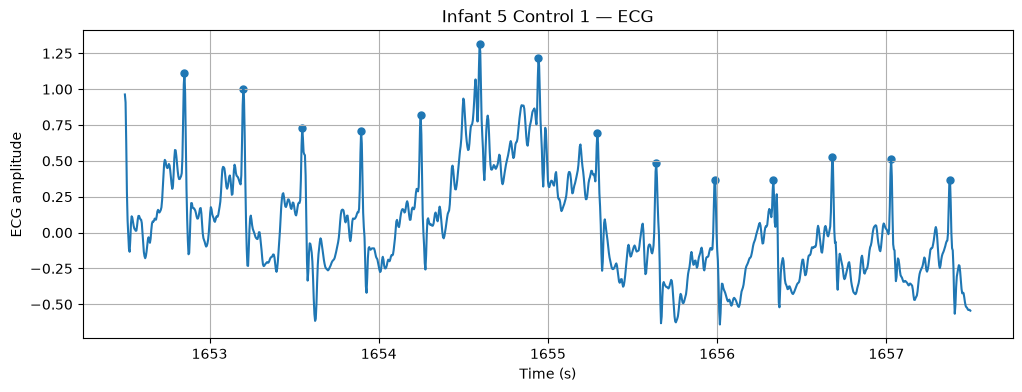

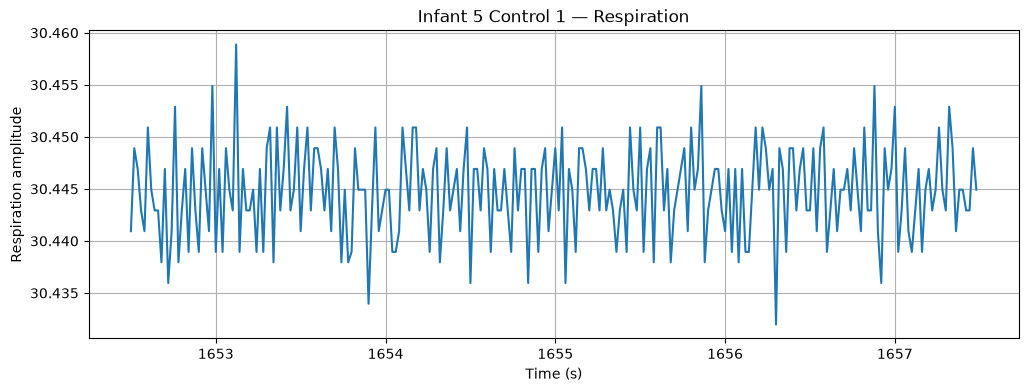


----------------------------------------------------------------------
CONTROL 2: 9837.500 - 9842.500 s
----------------------------------------------------------------------
Nearest known event distance: 3916.32 s

ECG samples: 1250
ECG mean: -0.2247
ECG std: 0.475731
ECG RMS: 0.526128
R-peak count: 13

Respiration samples: 250
Respiration mean: 0.931753
Respiration std: 0.003605
Respiration RMS: 0.93176
Respiration peak count: 0


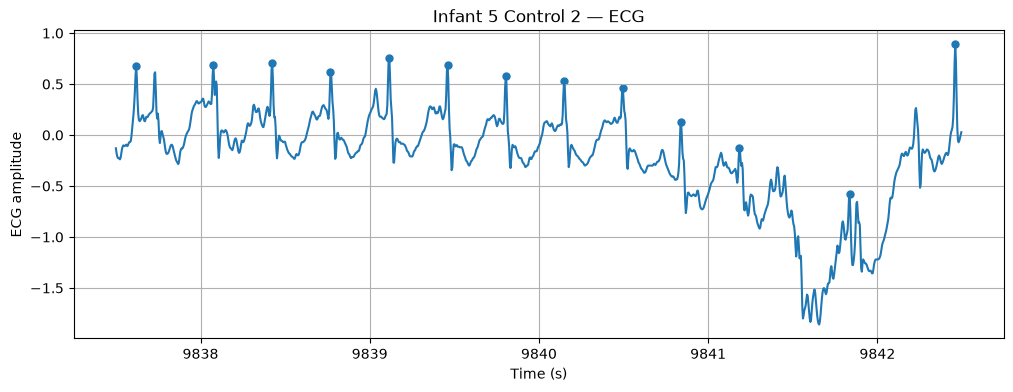

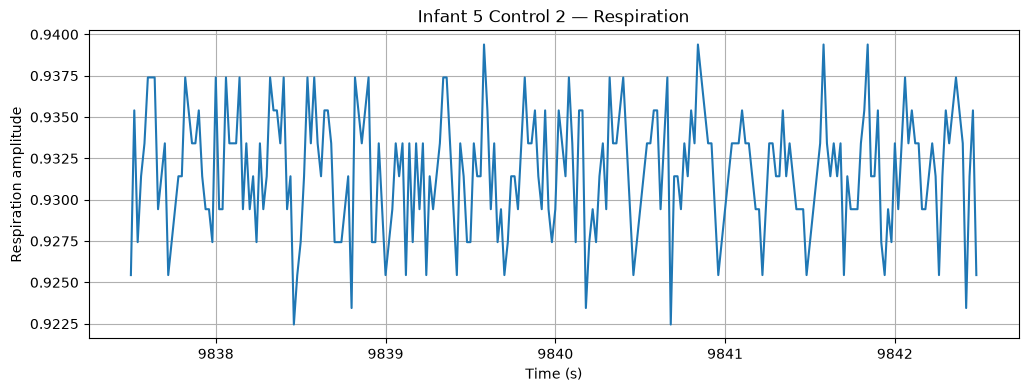

In [38]:
# Cell 20 — Visual and numerical validation of Infant 5 replacement controls

INFANT_VALIDATE = 5

SELECTED_CONTROLS = [
    1655.0,
    9840.0
]

info = record_info_df[
    record_info_df["infant"] == INFANT_VALIDATE
].iloc[0]

ecg_fs = float(info["ecg_fs"])
resp_fs = float(info["resp_fs"])

print("=" * 70)
print("INFANT 5 REPLACEMENT CONTROL VALIDATION")
print("=" * 70)

for control_number, center in enumerate(
    SELECTED_CONTROLS,
    start=1
):

    window_start = center - 2.5
    window_end = center + 2.5

    print()
    print("-" * 70)
    print(
        f"CONTROL {control_number}: "
        f"{window_start:.3f} - {window_end:.3f} s"
    )
    print("-" * 70)

    # --------------------------------------------------------
    # Check distance from known Infant 5 events
    # --------------------------------------------------------

    distances = np.abs(
        infant5_events - center
    )

    nearest_event_distance = np.min(distances)

    print(
        "Nearest known event distance:",
        round(nearest_event_distance, 3),
        "s"
    )

    # --------------------------------------------------------
    # Load ECG
    # --------------------------------------------------------

    ecg_start = int(
        round(window_start * ecg_fs)
    )

    ecg_end = int(
        round(window_end * ecg_fs)
    )

    ecg_record = wfdb.rdrecord(
        f"infant{INFANT_VALIDATE}_ecg",
        pn_dir="picsdb/1.0.0",
        sampfrom=ecg_start,
        sampto=ecg_end
    )

    ecg_signal = ecg_record.p_signal[:, 0]

    # --------------------------------------------------------
    # Load respiration
    # --------------------------------------------------------

    resp_start = int(
        round(window_start * resp_fs)
    )

    resp_end = int(
        round(window_end * resp_fs)
    )

    resp_record = wfdb.rdrecord(
        f"infant{INFANT_VALIDATE}_resp",
        pn_dir="picsdb/1.0.0",
        sampfrom=resp_start,
        sampto=resp_end
    )

    resp_signal = resp_record.p_signal[:, 0]

    # --------------------------------------------------------
    # ECG features
    # --------------------------------------------------------

    ecg_mean = np.mean(ecg_signal)
    ecg_std = np.std(ecg_signal)
    ecg_rms = np.sqrt(
        np.mean(ecg_signal ** 2)
    )

    r_peaks, _ = find_peaks(
        ecg_signal,
        distance=int(0.30 * ecg_fs),
        prominence=0.3
    )

    print()
    print("ECG samples:", len(ecg_signal))
    print("ECG mean:", round(ecg_mean, 6))
    print("ECG std:", round(ecg_std, 6))
    print("ECG RMS:", round(ecg_rms, 6))
    print("R-peak count:", len(r_peaks))

    # --------------------------------------------------------
    # Respiration features
    # --------------------------------------------------------

    resp_mean = np.mean(resp_signal)
    resp_std = np.std(resp_signal)
    resp_rms = np.sqrt(
        np.mean(resp_signal ** 2)
    )

    resp_peaks, _ = find_peaks(
        resp_signal,
        distance=max(1, int(0.8 * resp_fs)),
        prominence=0.1
    )

    print()
    print("Respiration samples:", len(resp_signal))
    print("Respiration mean:", round(resp_mean, 6))
    print("Respiration std:", round(resp_std, 6))
    print("Respiration RMS:", round(resp_rms, 6))
    print("Respiration peak count:", len(resp_peaks))

    # --------------------------------------------------------
    # Plot ECG
    # --------------------------------------------------------

    ecg_time = np.arange(
        len(ecg_signal)
    ) / ecg_fs + window_start

    plt.figure(figsize=(12, 4))
    plt.plot(ecg_time, ecg_signal)
    plt.scatter(
        ecg_time[r_peaks],
        ecg_signal[r_peaks],
        s=25
    )
    plt.title(
        f"Infant 5 Control {control_number} — ECG"
    )
    plt.xlabel("Time (s)")
    plt.ylabel("ECG amplitude")
    plt.grid(True)
    plt.show()

    # --------------------------------------------------------
    # Plot respiration
    # --------------------------------------------------------

    resp_time = np.arange(
        len(resp_signal)
    ) / resp_fs + window_start

    plt.figure(figsize=(12, 4))
    plt.plot(resp_time, resp_signal)
    plt.title(
        f"Infant 5 Control {control_number} — Respiration"
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Respiration amplitude")
    plt.grid(True)
    plt.show()

In [39]:
# Cell 21 — Select cleaner alternative Infant 5 control candidates

print("=" * 70)
print("CLEANER INFANT 5 CONTROL CANDIDATES")
print("=" * 70)

# Exclude the already selected/rejected regions
EXCLUDE_CENTERS = [1655.0, 9840.0]

candidate_pool = replacement_candidates_df.copy()

candidate_pool = candidate_pool[
    ~candidate_pool["center_s"].isin(EXCLUDE_CENTERS)
].copy()

# Prefer moderate ECG amplitude rather than extreme/artifactual amplitude
candidate_pool = candidate_pool[
    (candidate_pool["ecg_std"] >= 0.15) &
    (candidate_pool["ecg_std"] <= 0.40) &
    (candidate_pool["r_peak_count"] >= 8) &
    (candidate_pool["r_peak_count"] <= 18)
].copy()

# Sort by ECG quality
candidate_pool = candidate_pool.sort_values(
    ["r_peak_count", "ecg_std"],
    ascending=[False, False]
)

print()
print("Candidate pool size:", len(candidate_pool))

print()
print("Top cleaner candidates:")

display(
    candidate_pool.head(30)
)

CLEANER INFANT 5 CONTROL CANDIDATES

Candidate pool size: 1636

Top cleaner candidates:


,center_s,window_start_s,window_end_s,ecg_mean,ecg_std,ecg_rms,r_peak_count
1623,9870.0,9867.5,9872.5,0.047659,0.256694,0.261081,15
1626,9885.0,9882.5,9887.5,-0.073644,0.252053,0.262591,15
1629,9900.0,9897.5,9902.5,0.016634,0.248263,0.248819,15
1616,9835.0,9832.5,9837.5,-0.070364,0.247680,0.257481,15
1625,9880.0,9877.5,9882.5,0.004641,0.237218,0.237263,15
1627,9890.0,9887.5,9892.5,-0.020186,0.228194,0.229085,15
19,1730.0,1727.5,1732.5,-0.067791,0.228085,0.237946,15
1628,9895.0,9892.5,9897.5,-0.018945,0.227989,0.228775,15
6,1665.0,1662.5,1667.5,0.000111,0.222592,0.222592,15
36,1815.0,1812.5,1817.5,-0.039526,0.222093,0.225582,15


In [41]:
# Cell 22 — Recreate validated R-peak detector

def detect_r_peaks(ecg_signal, ecg_fs):
    """
    Validated R-peak detector used in the PICS event-detection workflow.
    """

    peaks, properties = find_peaks(
        ecg_signal,
        distance=int(0.30 * ecg_fs),
        prominence=0.3
    )

    return peaks, properties


print("R-peak detector ready.")
print("find_peaks:", find_peaks)

R-peak detector ready.
find_peaks: <function find_peaks at 0x0000026332687A60>


INFANT 5 — REPLACEMENT CONTROL CANDIDATE
Center: 1730.0 s
Window: 1727.5 to 1732.5 s
ECG sampling frequency: 250.0 Hz
Respiration sampling frequency: 50.0 Hz
Detected R-peaks: 15


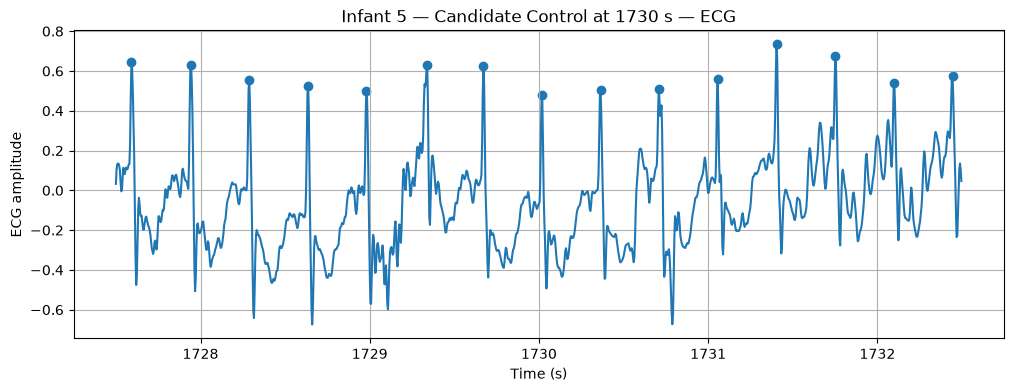

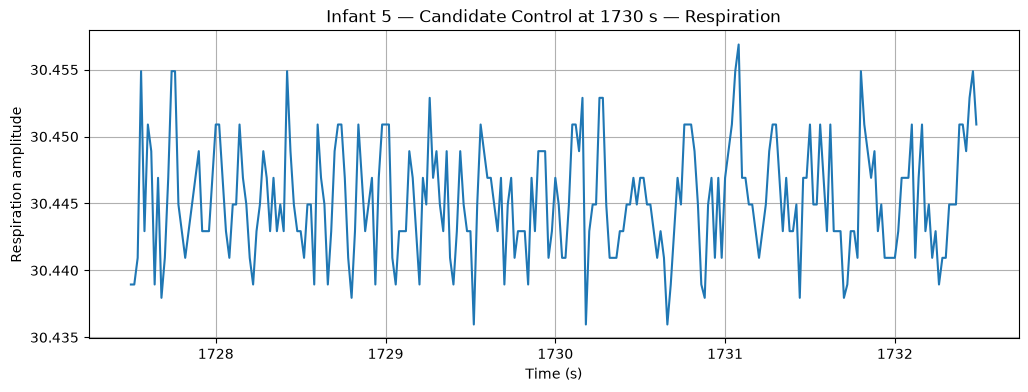

In [42]:
# Cell 22 — Visual validation of Infant 5 replacement candidate at 1730 s

TEST_CENTER = 1730.0
TEST_WINDOW = 5.0

infant = 5

info = record_info_df[
    record_info_df["infant"] == infant
].iloc[0]

ecg_fs = float(info["ecg_fs"])
resp_fs = float(info["resp_fs"])

window_start = TEST_CENTER - TEST_WINDOW / 2
window_end = TEST_CENTER + TEST_WINDOW / 2

ecg_start = int(round(window_start * ecg_fs))
ecg_end = int(round(window_end * ecg_fs))

resp_start = int(round(window_start * resp_fs))
resp_end = int(round(window_end * resp_fs))

# Load ECG
ecg_record = wfdb.rdrecord(
    f"infant{infant}_ecg",
    pn_dir="picsdb/1.0.0",
    sampfrom=ecg_start,
    sampto=ecg_end
)

ecg_signal = ecg_record.p_signal[:, 0]

# Load respiration
resp_record = wfdb.rdrecord(
    f"infant{infant}_resp",
    pn_dir="picsdb/1.0.0",
    sampfrom=resp_start,
    sampto=resp_end
)

resp_signal = resp_record.p_signal[:, 0]

# Detect ECG peaks
r_peaks, _ = detect_r_peaks(
    ecg_signal,
    ecg_fs
)

ecg_time = np.arange(len(ecg_signal)) / ecg_fs + window_start
resp_time = np.arange(len(resp_signal)) / resp_fs + window_start

print("=" * 70)
print("INFANT 5 — REPLACEMENT CONTROL CANDIDATE")
print("=" * 70)

print("Center:", TEST_CENTER, "s")
print("Window:", window_start, "to", window_end, "s")
print("ECG sampling frequency:", ecg_fs, "Hz")
print("Respiration sampling frequency:", resp_fs, "Hz")
print("Detected R-peaks:", len(r_peaks))

# ECG plot
plt.figure(figsize=(12, 4))

plt.plot(ecg_time, ecg_signal)

plt.scatter(
    ecg_time[r_peaks],
    ecg_signal[r_peaks],
    marker="o"
)

plt.title("Infant 5 — Candidate Control at 1730 s — ECG")
plt.xlabel("Time (s)")
plt.ylabel("ECG amplitude")
plt.grid(True)

plt.show()

# Respiration plot
plt.figure(figsize=(12, 4))

plt.plot(resp_time, resp_signal)

plt.title("Infant 5 — Candidate Control at 1730 s — Respiration")
plt.xlabel("Time (s)")
plt.ylabel("Respiration amplitude")
plt.grid(True)

plt.show()

In [43]:
# Cell 24 — Replace Infant 5 Control 1 with validated 1730 s window

INFANT_REPLACE = 5
REPLACEMENT_CENTER = 1730.0
CONTROL_WINDOW = 5.0

replacement_start = REPLACEMENT_CENTER - CONTROL_WINDOW / 2
replacement_end = REPLACEMENT_CENTER + CONTROL_WINDOW / 2

normal_control_windows.loc[
    (normal_control_windows["infant"] == INFANT_REPLACE) &
    (normal_control_windows["control_number"] == 1),
    "center_s"
] = REPLACEMENT_CENTER

normal_control_windows.loc[
    (normal_control_windows["infant"] == INFANT_REPLACE) &
    (normal_control_windows["control_number"] == 1),
    "window_start_s"
] = replacement_start

normal_control_windows.loc[
    (normal_control_windows["infant"] == INFANT_REPLACE) &
    (normal_control_windows["control_number"] == 1),
    "window_end_s"
] = replacement_end

print("=" * 70)
print("INFANT 5 CONTROL 1 REPLACED")
print("=" * 70)

display(
    normal_control_windows[
        (normal_control_windows["infant"] == INFANT_REPLACE)
    ]
)

INFANT 5 CONTROL 1 REPLACED


,infant,control_number,center_s,window_start_s,window_end_s,risk_label
8,5,1,1730.000000,1727.500000,1732.500000,0
9,5,2,471.252289,468.752289,473.752289,0


In [44]:
# Cell 25 — Regenerate features for Infant 5 normal controls

print("=" * 70)
print("REGENERATING INFANT 5 NORMAL CONTROL FEATURES")
print("=" * 70)

infant = 5

info = record_info_df[
    record_info_df["infant"] == infant
].iloc[0]

ecg_fs = float(info["ecg_fs"])
resp_fs = float(info["resp_fs"])

infant5_feature_rows = []

infant5_controls = normal_control_windows[
    normal_control_windows["infant"] == infant
].copy()

for _, window in infant5_controls.iterrows():

    control_number = int(window["control_number"])
    window_start = float(window["window_start_s"])
    window_end = float(window["window_end_s"])

    ecg_start = int(round(window_start * ecg_fs))
    ecg_end = int(round(window_end * ecg_fs))

    resp_start = int(round(window_start * resp_fs))
    resp_end = int(round(window_end * resp_fs))

    # Load ECG
    ecg_record = wfdb.rdrecord(
        f"infant{infant}_ecg",
        pn_dir="picsdb/1.0.0",
        sampfrom=ecg_start,
        sampto=ecg_end
    )

    ecg_signal = ecg_record.p_signal[:, 0]

    # Load respiration
    resp_record = wfdb.rdrecord(
        f"infant{infant}_resp",
        pn_dir="picsdb/1.0.0",
        sampfrom=resp_start,
        sampto=resp_end
    )

    resp_signal = resp_record.p_signal[:, 0]

    # Extract the same physiological features used for the dataset
    features = extract_window_features(
        ecg_signal,
        resp_signal,
        ecg_fs,
        resp_fs
    )

    features["infant"] = infant
    features["event_number"] = np.nan
    features["window_start_s"] = window_start
    features["window_end_s"] = window_end
    features["window_duration_s"] = window_end - window_start
    features["risk_label"] = 0
    features["window_type"] = "normal"
    features["control_number"] = control_number

    infant5_feature_rows.append(features)

infant5_features_new = pd.DataFrame(infant5_feature_rows)

print()
print("Infant 5 feature rows:", len(infant5_features_new))
print()

display(infant5_features_new)

REGENERATING INFANT 5 NORMAL CONTROL FEATURES

Infant 5 feature rows: 2



,ecg_mean,ecg_std,ecg_rms,r_peak_count,mean_rr,std_rr,mean_hr,min_hr,max_hr,std_hr,...,mean_resp_rate,std_resp_rate,infant,event_number,window_start_s,window_end_s,window_duration_s,risk_label,window_type,control_number
0,-0.067791,0.228085,0.237946,15,0.346571,0.005778,173.172849,166.666667,180.722892,2.902453,...,77.631725,10.279914,5,NaN,1727.500000,1732.500000,5.0,0,normal,1
1,0.000000,0.000000,0.000000,0,NaN,NaN,NaN,NaN,NaN,NaN,...,81.380345,18.335059,5,NaN,468.752289,473.752289,5.0,0,normal,2


INFANT 5 — SECOND REPLACEMENT CONTROL
Center: 1815.0 s
Window: 1812.5 to 1817.5 s
ECG sampling frequency: 250.0 Hz
Respiration sampling frequency: 50.0 Hz
Detected R-peaks: 15


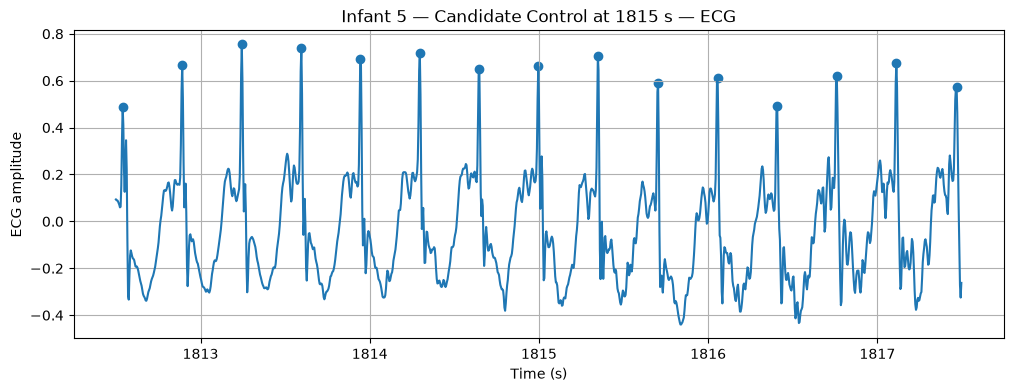

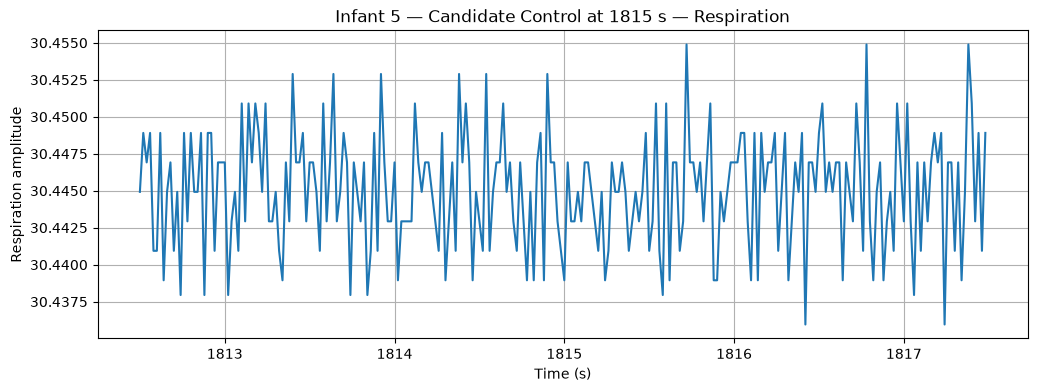

In [45]:
# Cell 26 — Visual validation of second Infant 5 replacement candidate

TEST_CENTER = 1815.0
TEST_WINDOW = 5.0

infant = 5

info = record_info_df[
    record_info_df["infant"] == infant
].iloc[0]

ecg_fs = float(info["ecg_fs"])
resp_fs = float(info["resp_fs"])

window_start = TEST_CENTER - TEST_WINDOW / 2
window_end = TEST_CENTER + TEST_WINDOW / 2

ecg_start = int(round(window_start * ecg_fs))
ecg_end = int(round(window_end * ecg_fs))

resp_start = int(round(window_start * resp_fs))
resp_end = int(round(window_end * resp_fs))

ecg_record = wfdb.rdrecord(
    f"infant{infant}_ecg",
    pn_dir="picsdb/1.0.0",
    sampfrom=ecg_start,
    sampto=ecg_end
)

ecg_signal = ecg_record.p_signal[:, 0]

resp_record = wfdb.rdrecord(
    f"infant{infant}_resp",
    pn_dir="picsdb/1.0.0",
    sampfrom=resp_start,
    sampto=resp_end
)

resp_signal = resp_record.p_signal[:, 0]

r_peaks, _ = detect_r_peaks(
    ecg_signal,
    ecg_fs
)

ecg_time = np.arange(len(ecg_signal)) / ecg_fs + window_start
resp_time = np.arange(len(resp_signal)) / resp_fs + window_start

print("=" * 70)
print("INFANT 5 — SECOND REPLACEMENT CONTROL")
print("=" * 70)

print("Center:", TEST_CENTER, "s")
print("Window:", window_start, "to", window_end, "s")
print("ECG sampling frequency:", ecg_fs, "Hz")
print("Respiration sampling frequency:", resp_fs, "Hz")
print("Detected R-peaks:", len(r_peaks))

plt.figure(figsize=(12, 4))

plt.plot(ecg_time, ecg_signal)

plt.scatter(
    ecg_time[r_peaks],
    ecg_signal[r_peaks],
    marker="o"
)

plt.title("Infant 5 — Candidate Control at 1815 s — ECG")
plt.xlabel("Time (s)")
plt.ylabel("ECG amplitude")
plt.grid(True)

plt.show()

plt.figure(figsize=(12, 4))

plt.plot(resp_time, resp_signal)

plt.title("Infant 5 — Candidate Control at 1815 s — Respiration")
plt.xlabel("Time (s)")
plt.ylabel("Respiration amplitude")
plt.grid(True)

plt.show()

In [46]:
# Cell 27 — Replace Infant 5 Control 2 with validated 1815 s window

INFANT_REPLACE = 5
REPLACEMENT_CENTER = 1815.0
CONTROL_NUMBER_REPLACE = 2
CONTROL_WINDOW = 5.0

replacement_start = REPLACEMENT_CENTER - CONTROL_WINDOW / 2
replacement_end = REPLACEMENT_CENTER + CONTROL_WINDOW / 2

mask = (
    (normal_control_windows["infant"] == INFANT_REPLACE) &
    (normal_control_windows["control_number"] == CONTROL_NUMBER_REPLACE)
)

normal_control_windows.loc[mask, "center_s"] = REPLACEMENT_CENTER
normal_control_windows.loc[mask, "window_start_s"] = replacement_start
normal_control_windows.loc[mask, "window_end_s"] = replacement_end

print("=" * 70)
print("INFANT 5 CONTROL 2 REPLACED")
print("=" * 70)

display(
    normal_control_windows[
        normal_control_windows["infant"] == INFANT_REPLACE
    ]
)

INFANT 5 CONTROL 2 REPLACED


,infant,control_number,center_s,window_start_s,window_end_s,risk_label
8,5,1,1730.0,1727.5,1732.5,0
9,5,2,1815.0,1812.5,1817.5,0


In [47]:
# Cell 28 — Regenerate final features for both Infant 5 controls

print("=" * 70)
print("REGENERATING FINAL INFANT 5 CONTROL FEATURES")
print("=" * 70)

infant = 5

info = record_info_df[
    record_info_df["infant"] == infant
].iloc[0]

ecg_fs = float(info["ecg_fs"])
resp_fs = float(info["resp_fs"])

infant5_feature_rows = []

infant5_controls = normal_control_windows[
    normal_control_windows["infant"] == infant
].sort_values("control_number")

for _, window in infant5_controls.iterrows():

    control_number = int(window["control_number"])
    window_start = float(window["window_start_s"])
    window_end = float(window["window_end_s"])

    ecg_start = int(round(window_start * ecg_fs))
    ecg_end = int(round(window_end * ecg_fs))

    resp_start = int(round(window_start * resp_fs))
    resp_end = int(round(window_end * resp_fs))

    ecg_record = wfdb.rdrecord(
        f"infant{infant}_ecg",
        pn_dir="picsdb/1.0.0",
        sampfrom=ecg_start,
        sampto=ecg_end
    )

    ecg_signal = ecg_record.p_signal[:, 0]

    resp_record = wfdb.rdrecord(
        f"infant{infant}_resp",
        pn_dir="picsdb/1.0.0",
        sampfrom=resp_start,
        sampto=resp_end
    )

    resp_signal = resp_record.p_signal[:, 0]

    features = extract_window_features(
        ecg_signal,
        resp_signal,
        ecg_fs,
        resp_fs
    )

    features["infant"] = infant
    features["event_number"] = np.nan
    features["window_start_s"] = window_start
    features["window_end_s"] = window_end
    features["window_duration_s"] = window_end - window_start
    features["risk_label"] = 0
    features["window_type"] = "normal"
    features["control_number"] = control_number

    infant5_feature_rows.append(features)

infant5_features_final = pd.DataFrame(infant5_feature_rows)

print()
print("Infant 5 final control rows:", len(infant5_features_final))
print()

display(
    infant5_features_final[
        [
            "infant",
            "control_number",
            "window_start_s",
            "window_end_s",
            "ecg_std",
            "ecg_rms",
            "r_peak_count",
            "mean_rr",
            "mean_hr",
            "sdnn",
            "rmssd"
        ]
    ]
)

REGENERATING FINAL INFANT 5 CONTROL FEATURES

Infant 5 final control rows: 2



,infant,control_number,window_start_s,window_end_s,ecg_std,ecg_rms,r_peak_count,mean_rr,mean_hr,sdnn,rmssd
0,5,1,1727.5,1732.5,0.228085,0.237946,15,0.346571,173.172849,0.005996,0.010168
1,5,2,1812.5,1817.5,0.222093,0.225582,15,0.352000,170.463980,0.002717,0.004000


In [48]:
# Cell 29 — Rebuild final normal-control feature table
# Infant 5 controls 1 and 2 now use the validated replacement windows

print("=" * 70)
print("REBUILDING FINAL NORMAL CONTROL FEATURE TABLE")
print("=" * 70)

# Start from the current normal-control feature table
final_normal_features = normal_features_df.copy()

# Remove the old Infant 5 control rows
final_normal_features = final_normal_features[
    ~(
        (final_normal_features["infant"] == 5)
    )
].copy()

# Add the newly regenerated Infant 5 controls
final_normal_features = pd.concat(
    [
        final_normal_features,
        infant5_features_new
    ],
    ignore_index=True
)

# Sort for clean organization
final_normal_features = final_normal_features.sort_values(
    ["infant", "control_number"]
).reset_index(drop=True)

print()
print("Final normal-control rows:", len(final_normal_features))
print("Number of infants:", final_normal_features["infant"].nunique())
print()

print("Rows per infant:")
display(
    final_normal_features.groupby("infant").size()
)

print()
print("Infant 5 final controls:")
display(
    final_normal_features[
        final_normal_features["infant"] == 5
    ]
)

print()
print("Feature table shape:", final_normal_features.shape)

REBUILDING FINAL NORMAL CONTROL FEATURE TABLE

Final normal-control rows: 20
Number of infants: 10

Rows per infant:


infant
1     2
2     2
3     2
4     2
5     2
6     2
7     2
8     2
9     2
10    2
dtype: int64


Infant 5 final controls:


,infant,event_number,window_start_s,window_end_s,window_duration_s,risk_label,window_type,control_number,ecg_mean,ecg_std,...,sdnn,rmssd,resp_mean,resp_std,resp_rms,resp_peak_count,mean_resp_interval,std_resp_interval,mean_resp_rate,std_resp_rate
8,5,NaN,1727.500000,1732.500000,5.0,0,normal,1,-0.067791,0.228085,...,0.005996,0.010168,30.445235,0.004187,30.445235,7,0.786667,0.104350,77.631725,10.279914
9,5,NaN,468.752289,473.752289,5.0,0,normal,2,0.000000,0.000000,...,NaN,NaN,30.444980,0.003856,30.444980,7,0.773333,0.163978,81.380345,18.335059



Feature table shape: (20, 28)


In [50]:
# Cell 31 — Directly regenerate and replace Infant 5 Control 2
# Validated replacement window: center = 1815 s

INFANT_FIX = 5
CONTROL_FIX = 2
CENTER_FIX = 1815.0
CONTROL_WINDOW = 5.0

print("=" * 70)
print("DIRECT FIX: INFANT 5 CONTROL 2")
print("=" * 70)

# Get Infant 5 sampling frequencies
info = record_info_df[
    record_info_df["infant"] == INFANT_FIX
].iloc[0]

ecg_fs = float(info["ecg_fs"])
resp_fs = float(info["resp_fs"])

window_start = CENTER_FIX - CONTROL_WINDOW / 2
window_end = CENTER_FIX + CONTROL_WINDOW / 2

# Sample ranges
ecg_start = int(round(window_start * ecg_fs))
ecg_end = int(round(window_end * ecg_fs))

resp_start = int(round(window_start * resp_fs))
resp_end = int(round(window_end * resp_fs))

print("Infant:", INFANT_FIX)
print("Control:", CONTROL_FIX)
print("Center:", CENTER_FIX, "s")
print("Window:", window_start, "to", window_end, "s")
print("ECG FS:", ecg_fs, "Hz")
print("Resp FS:", resp_fs, "Hz")

# Load ECG
ecg_record_fix = wfdb.rdrecord(
    f"infant{INFANT_FIX}_ecg",
    pn_dir="picsdb/1.0.0",
    sampfrom=ecg_start,
    sampto=ecg_end
)

ecg_signal_fix = ecg_record_fix.p_signal[:, 0]

# Load respiration
resp_record_fix = wfdb.rdrecord(
    f"infant{INFANT_FIX}_resp",
    pn_dir="picsdb/1.0.0",
    sampfrom=resp_start,
    sampto=resp_end
)

resp_signal_fix = resp_record_fix.p_signal[:, 0]

# Extract features using the established feature extractor
features_fix = extract_window_features(
    ecg_signal_fix,
    resp_signal_fix,
    ecg_fs,
    resp_fs
)

# Add required metadata
features_fix["infant"] = INFANT_FIX
features_fix["event_number"] = np.nan
features_fix["window_start_s"] = window_start
features_fix["window_end_s"] = window_end
features_fix["window_duration_s"] = CONTROL_WINDOW
features_fix["risk_label"] = 0
features_fix["window_type"] = "normal"
features_fix["control_number"] = CONTROL_FIX

# Convert to one-row DataFrame
infant5_control2_new = pd.DataFrame([features_fix])

print()
print("NEW INFANT 5 CONTROL 2 FEATURES")
print("=" * 70)

display(
    infant5_control2_new[
        [
            "infant",
            "control_number",
            "window_start_s",
            "window_end_s",
            "ecg_std",
            "ecg_rms",
            "r_peak_count",
            "mean_rr",
            "mean_hr",
            "sdnn",
            "rmssd"
        ]
    ]
)

DIRECT FIX: INFANT 5 CONTROL 2
Infant: 5
Control: 2
Center: 1815.0 s
Window: 1812.5 to 1817.5 s
ECG FS: 250.0 Hz
Resp FS: 50.0 Hz

NEW INFANT 5 CONTROL 2 FEATURES


,infant,control_number,window_start_s,window_end_s,ecg_std,ecg_rms,r_peak_count,mean_rr,mean_hr,sdnn,rmssd
0,5,2,1812.5,1817.5,0.222093,0.225582,15,0.352,170.46398,0.002717,0.004


In [51]:
# Cell 32 — Insert corrected Infant 5 Control 2 into final table

print("=" * 70)
print("UPDATING FINAL NORMAL-CONTROL TABLE")
print("=" * 70)

# Remove all Infant 5 rows
final_normal_features = final_normal_features[
    final_normal_features["infant"] != 5
].copy()

# Add corrected Infant 5 Control 1 and Control 2
final_normal_features = pd.concat(
    [
        final_normal_features,
        infant5_features_new.copy(),
        infant5_control2_new.copy()
    ],
    ignore_index=True
)

# Sort cleanly
final_normal_features = final_normal_features.sort_values(
    ["infant", "control_number"]
).reset_index(drop=True)

print()
print("Total rows:", len(final_normal_features))
print("Total infants:", final_normal_features["infant"].nunique())

print()
print("FINAL INFANT 5 CONTROLS:")
display(
    final_normal_features[
        final_normal_features["infant"] == 5
    ][
        [
            "infant",
            "control_number",
            "window_start_s",
            "window_end_s",
            "ecg_std",
            "ecg_rms",
            "r_peak_count",
            "mean_rr",
            "mean_hr",
            "sdnn",
            "rmssd"
        ]
    ]
)

UPDATING FINAL NORMAL-CONTROL TABLE

Total rows: 21
Total infants: 10

FINAL INFANT 5 CONTROLS:


,infant,control_number,window_start_s,window_end_s,ecg_std,ecg_rms,r_peak_count,mean_rr,mean_hr,sdnn,rmssd
8,5,1,1727.500000,1732.500000,0.228085,0.237946,15,0.346571,173.172849,0.005996,0.010168
9,5,2,468.752289,473.752289,0.000000,0.000000,0,NaN,NaN,NaN,NaN
10,5,2,1812.500000,1817.500000,0.222093,0.225582,15,0.352000,170.463980,0.002717,0.004000


In [52]:
# Cell 33 — Cleanly rebuild final normal-control table
# Keep validated Infant 5 Control 1 and Control 2 only

print("=" * 70)
print("CLEAN REBUILD OF FINAL NORMAL-CONTROL TABLE")
print("=" * 70)

# Remove ALL Infant 5 rows from the current table
final_normal_features = final_normal_features[
    final_normal_features["infant"] != 5
].copy()

# Get ONLY the validated Infant 5 Control 1
infant5_control1_final = infant5_features_new[
    infant5_features_new["control_number"] == 1
].copy()

# Get the validated Infant 5 Control 2
infant5_control2_final = infant5_control2_new.copy()

# Combine the two validated Infant 5 controls
infant5_final_controls = pd.concat(
    [
        infant5_control1_final,
        infant5_control2_final
    ],
    ignore_index=True
)

# Add them back
final_normal_features = pd.concat(
    [
        final_normal_features,
        infant5_final_controls
    ],
    ignore_index=True
)

# Sort cleanly
final_normal_features = final_normal_features.sort_values(
    ["infant", "control_number"]
).reset_index(drop=True)

print()
print("FINAL ROW COUNT:", len(final_normal_features))
print("FINAL INFANT COUNT:", final_normal_features["infant"].nunique())

print()
print("ROWS PER INFANT:")
display(
    final_normal_features.groupby("infant").size()
)

print()
print("FINAL INFANT 5 CONTROLS:")
display(
    final_normal_features[
        final_normal_features["infant"] == 5
    ][
        [
            "infant",
            "control_number",
            "window_start_s",
            "window_end_s",
            "ecg_std",
            "ecg_rms",
            "r_peak_count",
            "mean_rr",
            "mean_hr",
            "sdnn",
            "rmssd"
        ]
    ]
)

print()
print("FINAL FEATURE TABLE SHAPE:", final_normal_features.shape)

CLEAN REBUILD OF FINAL NORMAL-CONTROL TABLE

FINAL ROW COUNT: 20
FINAL INFANT COUNT: 10

ROWS PER INFANT:


infant
1     2
2     2
3     2
4     2
5     2
6     2
7     2
8     2
9     2
10    2
dtype: int64


FINAL INFANT 5 CONTROLS:


,infant,control_number,window_start_s,window_end_s,ecg_std,ecg_rms,r_peak_count,mean_rr,mean_hr,sdnn,rmssd
8,5,1,1727.5,1732.5,0.228085,0.237946,15,0.346571,173.172849,0.005996,0.010168
9,5,2,1812.5,1817.5,0.222093,0.225582,15,0.352000,170.463980,0.002717,0.004000



FINAL FEATURE TABLE SHAPE: (20, 28)


In [53]:
# Cell 34 — Final QC of all normal-control features

print("=" * 70)
print("FINAL QC — NORMAL CONTROL FEATURES")
print("=" * 70)

# Physiological feature columns
physio_features = [
    "ecg_mean",
    "ecg_std",
    "ecg_rms",
    "r_peak_count",
    "mean_rr",
    "std_rr",
    "mean_hr",
    "min_hr",
    "max_hr",
    "std_hr",
    "sdnn",
    "rmssd",
    "resp_mean",
    "resp_std",
    "resp_rms",
    "resp_peak_count",
    "mean_resp_interval",
    "std_resp_interval",
    "mean_resp_rate",
    "std_resp_rate"
]

# Check NaNs
nan_counts = final_normal_features[physio_features].isna().sum()

# Check infinities
inf_counts = np.isinf(
    final_normal_features[physio_features]
    .select_dtypes(include=[np.number])
).sum()

print()
print("Total rows:", len(final_normal_features))
print("Total infants:", final_normal_features["infant"].nunique())

print()
print("NaN counts:")
display(nan_counts)

print()
print("Infinite-value counts:")
display(inf_counts)

print()
print("Risk-label distribution:")
display(
    final_normal_features["risk_label"].value_counts()
)

print()
print("Window types:")
display(
    final_normal_features["window_type"].value_counts()
)

print()
print("Duplicate windows:")
print(
    final_normal_features[
        ["infant", "window_start_s", "window_end_s"]
    ].duplicated().sum()
)

# Overall pass/fail
nan_total = int(nan_counts.sum())
inf_total = int(inf_counts.sum())
duplicate_total = int(
    final_normal_features[
        ["infant", "window_start_s", "window_end_s"]
    ].duplicated().sum()
)

print()
print("=" * 70)

if (
    len(final_normal_features) == 20
    and final_normal_features["infant"].nunique() == 10
    and nan_total == 0
    and inf_total == 0
    and duplicate_total == 0
):
    print("QC STATUS: PASS")
else:
    print("QC STATUS: REVIEW REQUIRED")

print("=" * 70)

FINAL QC — NORMAL CONTROL FEATURES

Total rows: 20
Total infants: 10

NaN counts:


ecg_mean              0
ecg_std               0
ecg_rms               0
r_peak_count          0
mean_rr               0
std_rr                0
mean_hr               0
min_hr                0
max_hr                0
std_hr                0
sdnn                  0
rmssd                 0
resp_mean             0
resp_std              0
resp_rms              0
resp_peak_count       0
mean_resp_interval    0
std_resp_interval     0
mean_resp_rate        0
std_resp_rate         0
dtype: int64


Infinite-value counts:


ecg_mean              0
ecg_std               0
ecg_rms               0
r_peak_count          0
mean_rr               0
std_rr                0
mean_hr               0
min_hr                0
max_hr                0
std_hr                0
sdnn                  0
rmssd                 0
resp_mean             0
resp_std              0
resp_rms              0
resp_peak_count       0
mean_resp_interval    0
std_resp_interval     0
mean_resp_rate        0
std_resp_rate         0
dtype: int64


Risk-label distribution:


risk_label
0    20
Name: count, dtype: int64


Window types:


window_type
normal    20
Name: count, dtype: int64


Duplicate windows:
0

QC STATUS: PASS


In [54]:
# Cell 35 — Combine precursor and normal-control feature datasets

print("=" * 70)
print("COMBINING PRECURSOR + NORMAL CONTROL FEATURES")
print("=" * 70)

# Make independent copies
positive_features = precursor_features_df.copy()
negative_features = final_normal_features.copy()

# Combine
development_features_final = pd.concat(
    [
        positive_features,
        negative_features
    ],
    ignore_index=True
)

# Sort by infant, label, and time
development_features_final = development_features_final.sort_values(
    ["infant", "risk_label", "window_start_s"]
).reset_index(drop=True)

print()
print("Final development dataset shape:",
      development_features_final.shape)

print()
print("Risk-label distribution:")
display(
    development_features_final["risk_label"].value_counts()
    .sort_index()
)

print()
print("Rows per infant:")
display(
    development_features_final.groupby(
        ["infant", "risk_label"]
    ).size()
)

print()
print("Window types:")
display(
    development_features_final["window_type"].value_counts()
)

print()
print("First 10 rows:")
display(
    development_features_final.head(10)
)

COMBINING PRECURSOR + NORMAL CONTROL FEATURES

Final development dataset shape: (42, 28)

Risk-label distribution:


risk_label
0    20
1    22
Name: count, dtype: int64


Rows per infant:


infant  risk_label
1       0              2
        1             11
2       0              2
3       0              2
        1             11
4       0              2
5       0              2
6       0              2
7       0              2
8       0              2
9       0              2
10      0              2
dtype: int64


Window types:


window_type
precursor    22
normal       20
Name: count, dtype: int64


First 10 rows:


,infant,event_number,window_start_s,window_end_s,window_duration_s,risk_label,window_type,ecg_mean,ecg_std,ecg_rms,...,rmssd,resp_mean,resp_std,resp_rms,resp_peak_count,mean_resp_interval,std_resp_interval,mean_resp_rate,std_resp_rate,control_number
0,1,NaN,117.500000,122.500000,5.0,0,normal,-0.027689,0.129933,0.132851,...,0.003191,-0.232022,0.002647,0.232037,7,0.706000,0.165775,89.842028,20.972081,1.0
1,1,NaN,446.094717,451.094717,5.0,0,normal,-0.028517,0.140983,0.143838,...,0.003795,24.162096,0.633302,24.170394,5,0.905500,0.080578,66.775711,5.794057,2.0
2,1,2.0,3441.512000,3446.512000,5.0,1,precursor,-0.021984,0.171920,0.173319,...,0.002954,23.835691,0.938535,23.854161,6,0.829600,0.201166,76.961076,19.545060,NaN
3,1,2.0,3442.512000,3447.512000,5.0,1,precursor,-0.023708,0.175629,0.177222,...,0.003191,23.762278,0.888327,23.778877,5,1.121500,0.354103,58.880489,17.796450,NaN
4,1,2.0,3443.512000,3448.512000,5.0,1,precursor,-0.026837,0.179572,0.181567,...,0.002954,23.802280,0.757617,23.814334,5,1.179500,0.282932,53.350999,10.402689,NaN
5,1,2.0,3444.512000,3449.512000,5.0,1,precursor,-0.024609,0.192163,0.193732,...,0.003055,23.992864,0.873041,24.008743,4,1.404667,0.226253,43.916626,7.500382,NaN
6,1,2.0,3445.512000,3450.512000,5.0,1,precursor,-0.026618,0.193615,0.195436,...,0.003814,24.149320,0.905125,24.166277,4,1.413333,0.225993,43.644079,7.482993,NaN
7,1,2.0,3446.512000,3451.512000,5.0,1,precursor,-0.031588,0.203188,0.205629,...,0.008090,24.079127,0.832987,24.093531,3,1.281000,0.167000,47.648214,6.211750,NaN
8,1,2.0,3447.512000,3452.512000,5.0,1,precursor,-0.029986,0.204632,0.206817,...,0.010787,24.203522,0.762593,24.215532,3,1.499000,0.363000,42.520159,10.296743,NaN
9,1,2.0,3448.512000,3453.512000,5.0,1,precursor,-0.024214,0.207303,0.208712,...,0.014820,24.236538,0.742680,24.247915,3,1.499000,0.363000,42.520159,10.296743,NaN


In [55]:
# Cell 36 — Final QC of the combined development dataset

print("=" * 70)
print("FINAL QC — COMBINED DEVELOPMENT DATASET")
print("=" * 70)

# Physiological feature columns
physio_features = [
    "ecg_mean",
    "ecg_std",
    "ecg_rms",
    "r_peak_count",
    "mean_rr",
    "std_rr",
    "mean_hr",
    "min_hr",
    "max_hr",
    "std_hr",
    "sdnn",
    "rmssd",
    "resp_mean",
    "resp_std",
    "resp_rms",
    "resp_peak_count",
    "mean_resp_interval",
    "std_resp_interval",
    "mean_resp_rate",
    "std_resp_rate"
]

# Basic shape
print()
print("Dataset shape:", development_features_final.shape)

# Class distribution
print()
print("Risk-label distribution:")
display(
    development_features_final["risk_label"]
    .value_counts()
    .sort_index()
)

# Window-type distribution
print()
print("Window-type distribution:")
display(
    development_features_final["window_type"]
    .value_counts()
)

# NaN check
nan_counts = development_features_final[physio_features].isna().sum()

print()
print("NaN counts:")
display(nan_counts)

# Infinite check
inf_counts = np.isinf(
    development_features_final[physio_features]
    .select_dtypes(include=[np.number])
).sum()

print()
print("Infinite-value counts:")
display(inf_counts)

# Duplicate windows
duplicate_count = development_features_final.duplicated(
    subset=["infant", "window_start_s", "window_end_s"]
).sum()

print()
print("Duplicate windows:", duplicate_count)

# Check that each window has the expected duration
duration_check = np.isclose(
    development_features_final["window_duration_s"],
    5.0
)

print()
print("All windows exactly 5 s:",
      duration_check.all())

# Check class/window consistency
label_type_check = (
    ((development_features_final["risk_label"] == 1) &
     (development_features_final["window_type"] == "precursor"))
    |
    ((development_features_final["risk_label"] == 0) &
     (development_features_final["window_type"] == "normal"))
)

print("Risk-label/window-type consistency:",
      label_type_check.all())

print()
print("=" * 70)

if (
    development_features_final.shape == (42, 28)
    and nan_counts.sum() == 0
    and inf_counts.sum() == 0
    and duplicate_count == 0
    and duration_check.all()
    and label_type_check.all()
):
    print("QC STATUS: PASS")
else:
    print("QC STATUS: REVIEW REQUIRED")

print("=" * 70)

FINAL QC — COMBINED DEVELOPMENT DATASET

Dataset shape: (42, 28)

Risk-label distribution:


risk_label
0    20
1    22
Name: count, dtype: int64


Window-type distribution:


window_type
precursor    22
normal       20
Name: count, dtype: int64


NaN counts:


ecg_mean              0
ecg_std               0
ecg_rms               0
r_peak_count          0
mean_rr               0
std_rr                0
mean_hr               0
min_hr                0
max_hr                0
std_hr                0
sdnn                  0
rmssd                 0
resp_mean             0
resp_std              0
resp_rms              0
resp_peak_count       0
mean_resp_interval    0
std_resp_interval     0
mean_resp_rate        0
std_resp_rate         0
dtype: int64


Infinite-value counts:


ecg_mean              0
ecg_std               0
ecg_rms               0
r_peak_count          0
mean_rr               0
std_rr                0
mean_hr               0
min_hr                0
max_hr                0
std_hr                0
sdnn                  0
rmssd                 0
resp_mean             0
resp_std              0
resp_rms              0
resp_peak_count       0
mean_resp_interval    0
std_resp_interval     0
mean_resp_rate        0
std_resp_rate         0
dtype: int64


Duplicate windows: 0

All windows exactly 5 s: True
Risk-label/window-type consistency: True

QC STATUS: PASS


In [56]:
# Cell 37 — Save final combined precursor-risk development dataset

FINAL_DATASET_PATH = REPORTS_DIR / "pics_final_precursor_risk_development_features.csv"

development_features_final.to_csv(
    FINAL_DATASET_PATH,
    index=False
)

print("=" * 70)
print("FINAL DATASET SAVED")
print("=" * 70)

print()
print("Path:")
print(FINAL_DATASET_PATH)

print()
print("Rows:", len(development_features_final))
print("Columns:", len(development_features_final.columns))

print()
print("Class distribution:")
print(
    development_features_final["risk_label"]
    .value_counts()
    .sort_index()
)

print()
print("File exists:", FINAL_DATASET_PATH.exists())
print("=" * 70)

FINAL DATASET SAVED

Path:
C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_final_precursor_risk_development_features.csv

Rows: 42
Columns: 28

Class distribution:
risk_label
0    20
1    22
Name: count, dtype: int64

File exists: True


In [57]:
# Cell 38 — Reload saved dataset and verify integrity

reloaded_dataset = pd.read_csv(FINAL_DATASET_PATH)

print("=" * 70)
print("RELOAD VERIFICATION")
print("=" * 70)

print()
print("Reloaded shape:", reloaded_dataset.shape)

print()
print("Risk-label distribution:")
print(
    reloaded_dataset["risk_label"]
    .value_counts()
    .sort_index()
)

print()
print("Infant distribution:")
print(
    reloaded_dataset["infant"]
    .value_counts()
    .sort_index()
)

print()
print("Window-type distribution:")
print(
    reloaded_dataset["window_type"]
    .value_counts()
)

print()
print("Duplicate windows:",
      reloaded_dataset.duplicated(
          subset=["infant", "window_start_s", "window_end_s"]
      ).sum())

print()
print("Saved dataset successfully reloaded:",
      reloaded_dataset.shape == development_features_final.shape)

print("=" * 70)

RELOAD VERIFICATION

Reloaded shape: (42, 28)

Risk-label distribution:
risk_label
0    20
1    22
Name: count, dtype: int64

Infant distribution:
infant
1     13
2      2
3     13
4      2
5      2
6      2
7      2
8      2
9      2
10     2
Name: count, dtype: int64

Window-type distribution:
window_type
precursor    22
normal       20
Name: count, dtype: int64

Duplicate windows: 0

Saved dataset successfully reloaded: True


In [58]:
# Cell 39 — Final feature and metadata inspection

print("=" * 70)
print("FINAL DATASET FEATURE INSPECTION")
print("=" * 70)

print()
print("All columns:")
for i, col in enumerate(reloaded_dataset.columns):
    print(f"{i:2d}: {col}")

print()
print("Total columns:", len(reloaded_dataset.columns))

metadata_columns = [
    "infant",
    "event_number",
    "window_start_s",
    "window_end_s",
    "window_duration_s",
    "risk_label",
    "window_type",
    "control_number"
]

feature_columns = [
    col for col in reloaded_dataset.columns
    if col not in metadata_columns
]

print()
print("Metadata columns:", len(metadata_columns))
print(metadata_columns)

print()
print("Physiological feature columns:", len(feature_columns))
print(feature_columns)

print()
print("=" * 70)
print("FEATURE MATRIX SHAPE")
print("=" * 70)

X_final = reloaded_dataset[feature_columns].copy()
y_final = reloaded_dataset["risk_label"].copy()

print()
print("X shape:", X_final.shape)
print("y shape:", y_final.shape)

print()
print("Class counts:")
print(y_final.value_counts().sort_index())

print("=" * 70)

FINAL DATASET FEATURE INSPECTION

All columns:
 0: infant
 1: event_number
 2: window_start_s
 3: window_end_s
 4: window_duration_s
 5: risk_label
 6: window_type
 7: ecg_mean
 8: ecg_std
 9: ecg_rms
10: r_peak_count
11: mean_rr
12: std_rr
13: mean_hr
14: min_hr
15: max_hr
16: std_hr
17: sdnn
18: rmssd
19: resp_mean
20: resp_std
21: resp_rms
22: resp_peak_count
23: mean_resp_interval
24: std_resp_interval
25: mean_resp_rate
26: std_resp_rate
27: control_number

Total columns: 28

Metadata columns: 8
['infant', 'event_number', 'window_start_s', 'window_end_s', 'window_duration_s', 'risk_label', 'window_type', 'control_number']

Physiological feature columns: 20
['ecg_mean', 'ecg_std', 'ecg_rms', 'r_peak_count', 'mean_rr', 'std_rr', 'mean_hr', 'min_hr', 'max_hr', 'std_hr', 'sdnn', 'rmssd', 'resp_mean', 'resp_std', 'resp_rms', 'resp_peak_count', 'mean_resp_interval', 'std_resp_interval', 'mean_resp_rate', 'std_resp_rate']

FEATURE MATRIX SHAPE

X shape: (42, 20)
y shape: (42,)

Class cou

In [59]:
# Cell 40 — Verify all 20 ML features are usable

print("=" * 70)
print("FEATURE COMPLETENESS CHECK")
print("=" * 70)

feature_check = pd.DataFrame({
    "dtype": X_final.dtypes,
    "nan_count": X_final.isna().sum(),
    "inf_count": np.isinf(X_final).sum(),
    "unique_values": X_final.nunique(),
    "min": X_final.min(),
    "max": X_final.max()
})

display(feature_check)

print()
print("=" * 70)

all_numeric = all(
    pd.api.types.is_numeric_dtype(X_final[col])
    for col in X_final.columns
)

no_nan = X_final.isna().sum().sum() == 0
no_inf = np.isinf(X_final).sum().sum() == 0
all_variable = (X_final.nunique() > 1).all()

print("All features numeric:", all_numeric)
print("No NaN values:", no_nan)
print("No infinite values:", no_inf)
print("All features have variation:", all_variable)

print()
if all_numeric and no_nan and no_inf and all_variable:
    print("FEATURE STATUS: PASS")
else:
    print("FEATURE STATUS: REVIEW REQUIRED")

print("=" * 70)

FEATURE COMPLETENESS CHECK


,dtype,nan_count,inf_count,unique_values,min,max
ecg_mean,float64,0,0,42,-0.067791,-0.004141
ecg_std,float64,0,0,42,0.118249,0.428313
ecg_rms,float64,0,0,42,0.120911,0.433105
r_peak_count,int64,0,0,6,10.000000,15.000000
mean_rr,float64,0,0,42,0.327143,0.520000
std_rr,float64,0,0,42,0.000990,0.182776
mean_hr,float64,0,0,42,115.452503,183.407794
min_hr,float64,0,0,32,60.240964,182.926829
max_hr,float64,0,0,26,118.577075,184.049080
std_hr,float64,0,0,42,0.555370,32.909418



All features numeric: True
No NaN values: True
No infinite values: True
All features have variation: True

FEATURE STATUS: PASS


In [60]:
# Cell 41 — Class balance by infant

print("=" * 70)
print("CLASS BALANCE BY INFANT")
print("=" * 70)

class_balance = pd.crosstab(
    reloaded_dataset["infant"],
    reloaded_dataset["risk_label"]
)

# Ensure both classes are always shown
class_balance = class_balance.reindex(
    columns=[0, 1],
    fill_value=0
)

class_balance.columns = ["normal_0", "precursor_1"]

class_balance["total"] = (
    class_balance["normal_0"] +
    class_balance["precursor_1"]
)

display(class_balance)

print()
print("=" * 70)
print("SUMMARY")
print("=" * 70)

print()
print("Total infants:", reloaded_dataset["infant"].nunique())
print("Total windows:", len(reloaded_dataset))
print("Normal windows:", (reloaded_dataset["risk_label"] == 0).sum())
print("Precursor windows:", (reloaded_dataset["risk_label"] == 1).sum())

print()
print("Infants containing precursor windows:",
      reloaded_dataset.loc[
          reloaded_dataset["risk_label"] == 1,
          "infant"
      ].nunique())

print("=" * 70)

CLASS BALANCE BY INFANT


,normal_0,precursor_1,total
infant,,,
1,2,11,13
2,2,0,2
3,2,11,13
4,2,0,2
5,2,0,2
6,2,0,2
7,2,0,2
8,2,0,2
9,2,0,2



SUMMARY

Total infants: 10
Total windows: 42
Normal windows: 20
Precursor windows: 22

Infants containing precursor windows: 2


In [61]:
# Cell 42 — Verify precursor windows by infant and event

print("=" * 70)
print("PRECURSOR WINDOW DISTRIBUTION")
print("=" * 70)

precursor_only = reloaded_dataset[
    reloaded_dataset["risk_label"] == 1
].copy()

event_distribution = (
    precursor_only
    .groupby(["infant", "event_number"])
    .agg(
        window_count=("risk_label", "size"),
        first_window_s=("window_start_s", "min"),
        last_window_s=("window_end_s", "max")
    )
    .reset_index()
)

display(event_distribution)

print()
print("Total precursor windows:", len(precursor_only))

print()
print("Precursor windows per infant:")
display(
    precursor_only["infant"]
    .value_counts()
    .sort_index()
)

print()
print("=" * 70)

PRECURSOR WINDOW DISTRIBUTION


,infant,event_number,window_count,first_window_s,last_window_s
0,1,2.0,11,3441.512,3456.512
1,3,2.0,11,8128.846,8143.846



Total precursor windows: 22

Precursor windows per infant:


infant
1    11
3    11
Name: count, dtype: int64

In [62]:
# Cell 43 — Inspect exact precursor window progression

print("=" * 70)
print("EXACT PRECURSOR WINDOW PROGRESSION")
print("=" * 70)

precursor_windows = (
    reloaded_dataset[
        reloaded_dataset["risk_label"] == 1
    ][
        [
            "infant",
            "event_number",
            "window_start_s",
            "window_end_s",
            "window_duration_s",
            "risk_label",
            "window_type"
        ]
    ]
    .sort_values(
        ["infant", "event_number", "window_start_s"]
    )
    .reset_index(drop=True)
)

display(precursor_windows)

print()
print("=" * 70)

for (infant, event), group in precursor_windows.groupby(
    ["infant", "event_number"]
):
    print(
        f"Infant {int(infant)}, Event {int(event)}:"
    )
    print(
        f"  Number of windows: {len(group)}"
    )
    print(
        f"  First window: "
        f"{group['window_start_s'].iloc[0]:.3f} "
        f"to "
        f"{group['window_end_s'].iloc[0]:.3f} s"
    )
    print(
        f"  Last window:  "
        f"{group['window_start_s'].iloc[-1]:.3f} "
        f"to "
        f"{group['window_end_s'].iloc[-1]:.3f} s"
    )
    print(
        f"  Start-to-start step values: "
        f"{np.diff(group['window_start_s'].to_numpy())}"
    )
    print()

EXACT PRECURSOR WINDOW PROGRESSION


,infant,event_number,window_start_s,window_end_s,window_duration_s,risk_label,window_type
0,1,2.0,3441.512,3446.512,5.0,1,precursor
1,1,2.0,3442.512,3447.512,5.0,1,precursor
2,1,2.0,3443.512,3448.512,5.0,1,precursor
3,1,2.0,3444.512,3449.512,5.0,1,precursor
4,1,2.0,3445.512,3450.512,5.0,1,precursor
5,1,2.0,3446.512,3451.512,5.0,1,precursor
6,1,2.0,3447.512,3452.512,5.0,1,precursor
7,1,2.0,3448.512,3453.512,5.0,1,precursor
8,1,2.0,3449.512,3454.512,5.0,1,precursor
9,1,2.0,3450.512,3455.512,5.0,1,precursor



Infant 1, Event 2:
  Number of windows: 11
  First window: 3441.512 to 3446.512 s
  Last window:  3451.512 to 3456.512 s
  Start-to-start step values: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Infant 3, Event 2:
  Number of windows: 11
  First window: 8128.846 to 8133.846 s
  Last window:  8138.846 to 8143.846 s
  Start-to-start step values: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]



In [63]:
# Cell 44 — Check LOSO fold class support

print("=" * 70)
print("LOSO FOLD CLASS SUPPORT CHECK")
print("=" * 70)

feature_dataset = reloaded_dataset.copy()

loso_summary = []

for test_infant in sorted(feature_dataset["infant"].unique()):

    test_data = feature_dataset[
        feature_dataset["infant"] == test_infant
    ]

    train_data = feature_dataset[
        feature_dataset["infant"] != test_infant
    ]

    loso_summary.append({
        "test_infant": test_infant,
        "train_rows": len(train_data),
        "test_rows": len(test_data),
        "train_normal": int((train_data["risk_label"] == 0).sum()),
        "train_precursor": int((train_data["risk_label"] == 1).sum()),
        "test_normal": int((test_data["risk_label"] == 0).sum()),
        "test_precursor": int((test_data["risk_label"] == 1).sum())
    })

loso_summary_df = pd.DataFrame(loso_summary)

display(loso_summary_df)

print()
print("=" * 70)
print("FOLDS WITH BOTH CLASSES IN TEST SET")
print("=" * 70)

both_class_test_folds = loso_summary_df[
    (loso_summary_df["test_normal"] > 0) &
    (loso_summary_df["test_precursor"] > 0)
]

display(both_class_test_folds)

print()
print(
    "Number of LOSO folds with both test classes:",
    len(both_class_test_folds)
)

LOSO FOLD CLASS SUPPORT CHECK


,test_infant,train_rows,test_rows,train_normal,train_precursor,test_normal,test_precursor
0,1,29,13,18,11,2,11
1,2,40,2,18,22,2,0
2,3,29,13,18,11,2,11
3,4,40,2,18,22,2,0
4,5,40,2,18,22,2,0
5,6,40,2,18,22,2,0
6,7,40,2,18,22,2,0
7,8,40,2,18,22,2,0
8,9,40,2,18,22,2,0
9,10,40,2,18,22,2,0



FOLDS WITH BOTH CLASSES IN TEST SET


,test_infant,train_rows,test_rows,train_normal,train_precursor,test_normal,test_precursor
0,1,29,13,18,11,2,11
2,3,29,13,18,11,2,11



Number of LOSO folds with both test classes: 2


In [64]:
# Cell 45 — Define final ML feature matrix

print("=" * 70)
print("FINAL ML FEATURE SET")
print("=" * 70)

ML_FEATURES = [
    "ecg_mean",
    "ecg_std",
    "ecg_rms",
    "r_peak_count",
    "mean_rr",
    "std_rr",
    "mean_hr",
    "min_hr",
    "max_hr",
    "std_hr",
    "sdnn",
    "rmssd",
    "resp_mean",
    "resp_std",
    "resp_rms",
    "resp_peak_count",
    "mean_resp_interval",
    "std_resp_interval",
    "mean_resp_rate",
    "std_resp_rate"
]

X = feature_dataset[ML_FEATURES].copy()
y = feature_dataset["risk_label"].astype(int).copy()
groups = feature_dataset["infant"].copy()

print("Number of ML features:", len(ML_FEATURES))
print()
print("Feature names:")
for i, feature in enumerate(ML_FEATURES, start=1):
    print(f"{i:2d}. {feature}")

print()
print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)

print()
print("Class distribution:")
print(y.value_counts().sort_index())

print()
print("Number of subjects:", groups.nunique())
print("Subjects:", sorted(groups.unique()))

print()
print("=" * 70)
print("FEATURE MATRIX READY")
print("=" * 70)

FINAL ML FEATURE SET
Number of ML features: 20

Feature names:
 1. ecg_mean
 2. ecg_std
 3. ecg_rms
 4. r_peak_count
 5. mean_rr
 6. std_rr
 7. mean_hr
 8. min_hr
 9. max_hr
10. std_hr
11. sdnn
12. rmssd
13. resp_mean
14. resp_std
15. resp_rms
16. resp_peak_count
17. mean_resp_interval
18. std_resp_interval
19. mean_resp_rate
20. std_resp_rate

X shape: (42, 20)
y shape: (42,)
groups shape: (42,)

Class distribution:
risk_label
0    20
1    22
Name: count, dtype: int64

Number of subjects: 10
Subjects: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

FEATURE MATRIX READY


In [65]:
# Cell 46 — Inspect feature ranges before scaling

print("=" * 70)
print("FEATURE RANGE INSPECTION")
print("=" * 70)

feature_range_df = pd.DataFrame({
    "min": X.min(),
    "max": X.max(),
    "mean": X.mean(),
    "std": X.std()
})

display(feature_range_df)

print()
print("=" * 70)
print("LARGEST FEATURE SCALES")
print("=" * 70)

display(
    feature_range_df
    .sort_values("max", ascending=False)
)

print()
print("=" * 70)
print("SCALING WILL BE FIT INSIDE EACH LOSO TRAINING FOLD")
print("=" * 70)

FEATURE RANGE INSPECTION


,min,max,mean,std
ecg_mean,-0.067791,-0.004141,-0.027361,0.010909
ecg_std,0.118249,0.428313,0.199969,0.068102
ecg_rms,0.120911,0.433105,0.202088,0.068200
r_peak_count,10.000000,15.000000,11.857143,1.661199
mean_rr,0.327143,0.520000,0.429505,0.057032
std_rr,0.000990,0.182776,0.013063,0.028886
mean_hr,115.452503,183.407794,142.639711,19.334617
min_hr,60.240964,182.926829,135.159828,23.053146
max_hr,118.577075,184.049080,146.644431,20.124960
std_hr,0.555370,32.909418,3.516047,5.613460



LARGEST FEATURE SCALES


,min,max,mean,std
max_hr,118.577075,184.049080,146.644431,20.124960
mean_hr,115.452503,183.407794,142.639711,19.334617
min_hr,60.240964,182.926829,135.159828,23.053146
mean_resp_rate,30.927835,110.833333,71.929566,18.947303
std_resp_rate,0.000000,44.147154,16.091202,8.801047
resp_rms,0.232037,34.816668,22.032911,6.695969
resp_mean,-1.101466,34.750592,21.949899,6.908697
std_hr,0.555370,32.909418,3.516047,5.613460
r_peak_count,10.000000,15.000000,11.857143,1.661199
resp_peak_count,2.000000,9.000000,5.523810,1.699901



SCALING WILL BE FIT INSIDE EACH LOSO TRAINING FOLD


In [66]:
# Cell 47 — Check for constant or near-constant ML features

print("=" * 70)
print("CONSTANT / NEAR-CONSTANT FEATURE CHECK")
print("=" * 70)

feature_variance_df = pd.DataFrame({
    "variance": X.var(),
    "std": X.std(),
    "unique_values": X.nunique()
})

display(
    feature_variance_df.sort_values(
        "variance",
        ascending=True
    )
)

constant_features = feature_variance_df[
    feature_variance_df["variance"] == 0
].index.tolist()

near_constant_features = feature_variance_df[
    feature_variance_df["unique_values"] <= 2
].index.tolist()

print()
print("Constant features:", constant_features)
print("Number of constant features:", len(constant_features))

print()
print("Features with <= 2 unique values:")
print(near_constant_features)
print(
    "Number of near-constant features:",
    len(near_constant_features)
)

print()
print("=" * 70)
print("FEATURE VARIABILITY CHECK COMPLETE")
print("=" * 70)

CONSTANT / NEAR-CONSTANT FEATURE CHECK


,variance,std,unique_values
ecg_mean,0.000119,0.010909,42
std_rr,0.000834,0.028886,42
sdnn,0.000912,0.030203,42
rmssd,0.001859,0.043119,39
mean_rr,0.003253,0.057032,42
ecg_std,0.004638,0.068102,42
ecg_rms,0.004651,0.068200,42
std_resp_interval,0.031696,0.178034,41
mean_resp_interval,0.095202,0.308548,40
resp_std,0.363670,0.603051,42



Constant features: []
Number of constant features: 0

Features with <= 2 unique values:
[]
Number of near-constant features: 0

FEATURE VARIABILITY CHECK COMPLETE


In [67]:
# Cell 48 — Prepare LOSO preprocessing

from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("LOSO PREPROCESSING SETUP")
print("=" * 70)

print("Feature matrix:", X.shape)
print("Labels:", y.shape)
print("Subjects:", groups.nunique())

print()
print("Scaler: StandardScaler")
print("Scaling policy:")
print("  - Fit scaler ONLY on LOSO training data")
print("  - Transform training data with fitted scaler")
print("  - Transform held-out infant with the same scaler")
print("  - Never fit scaler on the held-out infant")

# Store the scaler class for use inside each LOSO fold.
SCALER_CLASS = StandardScaler

print()
print("=" * 70)
print("LOSO PREPROCESSING READY")
print("=" * 70)

LOSO PREPROCESSING SETUP
Feature matrix: (42, 20)
Labels: (42,)
Subjects: 10

Scaler: StandardScaler
Scaling policy:
  - Fit scaler ONLY on LOSO training data
  - Transform training data with fitted scaler
  - Transform held-out infant with the same scaler
  - Never fit scaler on the held-out infant

LOSO PREPROCESSING READY


In [68]:
# Cell 49 — Build LOSO fold indices

print("=" * 70)
print("BUILDING LOSO FOLDS")
print("=" * 70)

loso_folds = []

for test_infant in sorted(groups.unique()):

    test_mask = groups == test_infant
    train_mask = ~test_mask

    train_indices = X.index[train_mask].to_numpy()
    test_indices = X.index[test_mask].to_numpy()

    loso_folds.append({
        "test_infant": int(test_infant),
        "train_indices": train_indices,
        "test_indices": test_indices
    })

print("Number of LOSO folds:", len(loso_folds))
print()

for fold in loso_folds:
    test_infant = fold["test_infant"]
    train_indices = fold["train_indices"]
    test_indices = fold["test_indices"]

    train_labels = y.loc[train_indices]
    test_labels = y.loc[test_indices]

    print(
        f"Infant {test_infant:2d} held out | "
        f"train={len(train_indices):2d} "
        f"(normal={(train_labels == 0).sum():2d}, "
        f"precursor={(train_labels == 1).sum():2d}) | "
        f"test={len(test_indices):2d} "
        f"(normal={(test_labels == 0).sum():2d}, "
        f"precursor={(test_labels == 1).sum():2d})"
    )

print()
print("=" * 70)
print("LOSO FOLDS READY")
print("=" * 70)

BUILDING LOSO FOLDS
Number of LOSO folds: 10

Infant  1 held out | train=29 (normal=18, precursor=11) | test=13 (normal= 2, precursor=11)
Infant  2 held out | train=40 (normal=18, precursor=22) | test= 2 (normal= 2, precursor= 0)
Infant  3 held out | train=29 (normal=18, precursor=11) | test=13 (normal= 2, precursor=11)
Infant  4 held out | train=40 (normal=18, precursor=22) | test= 2 (normal= 2, precursor= 0)
Infant  5 held out | train=40 (normal=18, precursor=22) | test= 2 (normal= 2, precursor= 0)
Infant  6 held out | train=40 (normal=18, precursor=22) | test= 2 (normal= 2, precursor= 0)
Infant  7 held out | train=40 (normal=18, precursor=22) | test= 2 (normal= 2, precursor= 0)
Infant  8 held out | train=40 (normal=18, precursor=22) | test= 2 (normal= 2, precursor= 0)
Infant  9 held out | train=40 (normal=18, precursor=22) | test= 2 (normal= 2, precursor= 0)
Infant 10 held out | train=40 (normal=18, precursor=22) | test= 2 (normal= 2, precursor= 0)

LOSO FOLDS READY


In [69]:
# Cell 50 — Verify LOSO scaler isolation

from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("VERIFYING LOSO SCALER ISOLATION")
print("=" * 70)

scaler_checks = []

for fold in loso_folds:

    test_infant = fold["test_infant"]
    train_indices = fold["train_indices"]
    test_indices = fold["test_indices"]

    X_train = X.loc[train_indices, ML_FEATURES]
    X_test = X.loc[test_indices, ML_FEATURES]

    scaler = StandardScaler()

    # Fit ONLY on training infants
    X_train_scaled = scaler.fit_transform(X_train)

    # Transform held-out infant using the training-fitted scaler
    X_test_scaled = scaler.transform(X_test)

    # Verify training transformed data is approximately zero mean / unit variance
    train_mean_max = np.abs(X_train_scaled.mean(axis=0)).max()
    train_std_max_error = np.abs(
        X_train_scaled.std(axis=0) - 1.0
    ).max()

    scaler_checks.append({
        "test_infant": test_infant,
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "max_abs_train_mean": train_mean_max,
        "max_train_std_error": train_std_max_error,
        "train_scaled_finite": np.isfinite(X_train_scaled).all(),
        "test_scaled_finite": np.isfinite(X_test_scaled).all()
    })

scaler_check_df = pd.DataFrame(scaler_checks)

display(scaler_check_df)

print()
print("=" * 70)
print("SCALER ISOLATION STATUS")
print("=" * 70)

print(
    "All training means approximately zero:",
    (scaler_check_df["max_abs_train_mean"] < 1e-10).all()
)

print(
    "All training standard deviations approximately one:",
    (scaler_check_df["max_train_std_error"] < 1e-10).all()
)

print(
    "All scaled values finite:",
    scaler_check_df["train_scaled_finite"].all()
    and scaler_check_df["test_scaled_finite"].all()
)

print("=" * 70)

VERIFYING LOSO SCALER ISOLATION


,test_infant,train_rows,test_rows,max_abs_train_mean,max_train_std_error,train_scaled_finite,test_scaled_finite
0,1,29,13,1.102566e-15,1.110223e-16,True,True
1,2,40,2,4.884981e-16,2.220446e-16,True,True
2,3,29,13,1.253786e-15,2.220446e-16,True,True
3,4,40,2,5.995204e-16,2.220446e-16,True,True
4,5,40,2,1.498801e-15,2.220446e-16,True,True
5,6,40,2,8.548717e-16,2.220446e-16,True,True
6,7,40,2,1.809664e-15,2.220446e-16,True,True
7,8,40,2,8.215650e-16,2.220446e-16,True,True
8,9,40,2,1.632028e-15,2.220446e-16,True,True
9,10,40,2,1.865175e-15,2.220446e-16,True,True



SCALER ISOLATION STATUS
All training means approximately zero: True
All training standard deviations approximately one: True
All scaled values finite: True


In [70]:
# Cell 51 — Prepare and verify Logistic Regression on LOSO Fold 1

from sklearn.linear_model import LogisticRegression

TEST_INFANT = 1

fold_1 = next(
    fold for fold in loso_folds
    if fold["test_infant"] == TEST_INFANT
)

train_indices = fold_1["train_indices"]
test_indices = fold_1["test_indices"]

X_train = X.loc[train_indices, ML_FEATURES]
y_train = y.loc[train_indices]

X_test = X.loc[test_indices, ML_FEATURES]
y_test = y.loc[test_indices]

# Fit scaler ONLY on training data
fold_scaler = StandardScaler()

X_train_scaled = fold_scaler.fit_transform(X_train)
X_test_scaled = fold_scaler.transform(X_test)

# Baseline classifier
baseline_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

baseline_model.fit(
    X_train_scaled,
    y_train
)

train_predictions = baseline_model.predict(X_train_scaled)
test_predictions = baseline_model.predict(X_test_scaled)

print("=" * 70)
print("LOS0 FOLD 1 — LOGISTIC REGRESSION BASELINE")
print("=" * 70)

print("Held-out infant:", TEST_INFANT)
print()
print("Training samples:", len(y_train))
print("Test samples:", len(y_test))

print()
print("Training class distribution:")
print(y_train.value_counts().sort_index())

print()
print("Test class distribution:")
print(y_test.value_counts().sort_index())

print()
print("Predicted training classes:")
print(pd.Series(train_predictions).value_counts().sort_index())

print()
print("Predicted test classes:")
print(pd.Series(test_predictions).value_counts().sort_index())

print()
print("=" * 70)
print("MODEL STATUS")
print("=" * 70)
print("Model fitted successfully:", True)
print("Training predictions generated:", len(train_predictions))
print("Test predictions generated:", len(test_predictions))
print("Test predictions finite:", np.isfinite(test_predictions).all())
print("=" * 70)

LOS0 FOLD 1 — LOGISTIC REGRESSION BASELINE
Held-out infant: 1

Training samples: 29
Test samples: 13

Training class distribution:
risk_label
0    18
1    11
Name: count, dtype: int64

Test class distribution:
risk_label
0     2
1    11
Name: count, dtype: int64

Predicted training classes:
0    15
1    14
Name: count, dtype: int64

Predicted test classes:
0    13
Name: count, dtype: int64

MODEL STATUS
Model fitted successfully: True
Training predictions generated: 29
Test predictions generated: 13
Test predictions finite: True


In [71]:
# Cell 52 — Evaluate Logistic Regression on LOSO Fold 1

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Confusion matrix
cm_fold1 = confusion_matrix(
    y_test,
    test_predictions,
    labels=[0, 1]
)

tn, fp, fn, tp = cm_fold1.ravel()

# Classification metrics
accuracy_fold1 = accuracy_score(
    y_test,
    test_predictions
)

precision_fold1 = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

recall_fold1 = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

f1_fold1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)

# ROC-AUC requires probability scores
test_probabilities = baseline_model.predict_proba(
    X_test_scaled
)[:, 1]

if len(np.unique(y_test)) == 2:
    auc_fold1 = roc_auc_score(
        y_test,
        test_probabilities
    )
else:
    auc_fold1 = np.nan

print("=" * 70)
print("LOS0 FOLD 1 — LOGISTIC REGRESSION EVALUATION")
print("=" * 70)

print("Held-out infant:", TEST_INFANT)
print()

print("Confusion Matrix:")
print(cm_fold1)

print()
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print()
print("Accuracy :", round(accuracy_fold1, 4))
print("Precision:", round(precision_fold1, 4))
print("Recall   :", round(recall_fold1, 4))
print("F1-score :", round(f1_fold1, 4))
print("ROC-AUC  :", round(auc_fold1, 4))

print()
print("=" * 70)
print("FOLD 1 EVALUATION COMPLETE")
print("=" * 70)

LOS0 FOLD 1 — LOGISTIC REGRESSION EVALUATION
Held-out infant: 1

Confusion Matrix:
[[ 2  0]
 [11  0]]

TN: 2
FP: 0
FN: 11
TP: 0

Accuracy : 0.1538
Precision: 0.0
Recall   : 0.0
F1-score : 0.0
ROC-AUC  : 0.5455

FOLD 1 EVALUATION COMPLETE


In [72]:
# Cell 53 — Complete 10-fold LOSO Logistic Regression baseline

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

loso_baseline_results = []

for fold in loso_folds:

    test_infant = fold["test_infant"]
    train_indices = fold["train_indices"]
    test_indices = fold["test_indices"]

    # ------------------------------------------------------------
    # Split using LOSO indices
    # ------------------------------------------------------------
    X_train = X.loc[train_indices, ML_FEATURES]
    y_train = y.loc[train_indices]

    X_test = X.loc[test_indices, ML_FEATURES]
    y_test = y.loc[test_indices]

    # ------------------------------------------------------------
    # Fit scaler ONLY on training data
    # ------------------------------------------------------------
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # ------------------------------------------------------------
    # Balanced Logistic Regression
    # ------------------------------------------------------------
    model = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    # ------------------------------------------------------------
    # Predictions and probabilities
    # ------------------------------------------------------------
    predictions = model.predict(X_test_scaled)

    probabilities = model.predict_proba(
        X_test_scaled
    )[:, 1]

    # ------------------------------------------------------------
    # Confusion matrix
    # ------------------------------------------------------------
    cm = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    # ------------------------------------------------------------
    # Classification metrics
    # ------------------------------------------------------------
    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    # ROC-AUC only when both classes exist in test set
    if len(np.unique(y_test)) == 2:
        auc = roc_auc_score(
            y_test,
            probabilities
        )
    else:
        auc = np.nan

    # ------------------------------------------------------------
    # Store fold result
    # ------------------------------------------------------------
    loso_baseline_results.append({
        "test_infant": test_infant,
        "train_rows": len(y_train),
        "test_rows": len(y_test),
        "test_normal": int((y_test == 0).sum()),
        "test_precursor": int((y_test == 1).sum()),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": auc
    })

loso_baseline_results_df = pd.DataFrame(
    loso_baseline_results
)

print("=" * 70)
print("10-FOLD LOSO — LOGISTIC REGRESSION BASELINE")
print("=" * 70)

display(
    loso_baseline_results_df[
        [
            "test_infant",
            "test_rows",
            "test_normal",
            "test_precursor",
            "tn",
            "fp",
            "fn",
            "tp",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ]
    ]
)

print()
print("=" * 70)
print("LOS0 BASELINE COMPLETE")
print("=" * 70)

print("Number of folds:", len(loso_baseline_results_df))
print(
    "Folds with both test classes:",
    loso_baseline_results_df["roc_auc"].notna().sum()
)
print(
    "Folds with single test class:",
    loso_baseline_results_df["roc_auc"].isna().sum()
)

10-FOLD LOSO — LOGISTIC REGRESSION BASELINE


,test_infant,test_rows,test_normal,test_precursor,tn,fp,fn,tp,accuracy,precision,recall,f1,roc_auc
0,1,13,2,11,2,0,11,0,0.153846,0.0,0.000000,0.000000,0.545455
1,2,2,2,0,0,2,0,0,0.000000,0.0,0.000000,0.000000,NaN
2,3,13,2,11,1,1,10,1,0.153846,0.5,0.090909,0.153846,0.500000
3,4,2,2,0,1,1,0,0,0.500000,0.0,0.000000,0.000000,NaN
4,5,2,2,0,0,2,0,0,0.000000,0.0,0.000000,0.000000,NaN
5,6,2,2,0,2,0,0,0,1.000000,0.0,0.000000,0.000000,NaN
6,7,2,2,0,2,0,0,0,1.000000,0.0,0.000000,0.000000,NaN
7,8,2,2,0,1,1,0,0,0.500000,0.0,0.000000,0.000000,NaN
8,9,2,2,0,1,1,0,0,0.500000,0.0,0.000000,0.000000,NaN
9,10,2,2,0,1,1,0,0,0.500000,0.0,0.000000,0.000000,NaN



LOS0 BASELINE COMPLETE
Number of folds: 10
Folds with both test classes: 2
Folds with single test class: 8


In [73]:
# Cell 54 — Summarize valid LOSO baseline performance

valid_loso = loso_baseline_results_df[
    loso_baseline_results_df["roc_auc"].notna()
].copy()

print("=" * 70)
print("LOGISTIC REGRESSION — LOSO BASELINE SUMMARY")
print("=" * 70)

print()
print("Total LOSO folds:", len(loso_baseline_results_df))
print("Folds with both test classes:", len(valid_loso))
print(
    "Folds with single test class:",
    loso_baseline_results_df["roc_auc"].isna().sum()
)

print()
print("=" * 70)
print("VALID DISCRIMINATION FOLDS")
print("=" * 70)

display(
    valid_loso[
        [
            "test_infant",
            "test_normal",
            "test_precursor",
            "tn",
            "fp",
            "fn",
            "tp",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ]
    ]
)

# ------------------------------------------------------------
# Pooled confusion matrix across valid folds only
# ------------------------------------------------------------

pooled_tn = valid_loso["tn"].sum()
pooled_fp = valid_loso["fp"].sum()
pooled_fn = valid_loso["fn"].sum()
pooled_tp = valid_loso["tp"].sum()

pooled_total = (
    pooled_tn +
    pooled_fp +
    pooled_fn +
    pooled_tp
)

pooled_accuracy = (
    pooled_tn + pooled_tp
) / pooled_total

pooled_precision = (
    pooled_tp / (pooled_tp + pooled_fp)
    if (pooled_tp + pooled_fp) > 0
    else 0.0
)

pooled_recall = (
    pooled_tp / (pooled_tp + pooled_fn)
    if (pooled_tp + pooled_fn) > 0
    else 0.0
)

pooled_f1 = (
    2 * pooled_precision * pooled_recall /
    (pooled_precision + pooled_recall)
    if (pooled_precision + pooled_recall) > 0
    else 0.0
)

print()
print("=" * 70)
print("POOLED CONFUSION MATRIX — VALID FOLDS")
print("=" * 70)

print(
    np.array([
        [pooled_tn, pooled_fp],
        [pooled_fn, pooled_tp]
    ])
)

print()
print("TN:", pooled_tn)
print("FP:", pooled_fp)
print("FN:", pooled_fn)
print("TP:", pooled_tp)

print()
print("Pooled accuracy :", round(pooled_accuracy, 4))
print("Pooled precision:", round(pooled_precision, 4))
print("Pooled recall   :", round(pooled_recall, 4))
print("Pooled F1       :", round(pooled_f1, 4))

print()
print("=" * 70)
print("MEAN ± STD ACROSS VALID FOLDS")
print("=" * 70)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]:
    mean_value = valid_loso[metric].mean()
    std_value = valid_loso[metric].std(ddof=1)

    print(
        f"{metric:10s}: "
        f"{mean_value:.4f} ± {std_value:.4f}"
    )

print()
print("=" * 70)
print("BASELINE SUMMARY COMPLETE")
print("=" * 70)

LOGISTIC REGRESSION — LOSO BASELINE SUMMARY

Total LOSO folds: 10
Folds with both test classes: 2
Folds with single test class: 8

VALID DISCRIMINATION FOLDS


,test_infant,test_normal,test_precursor,tn,fp,fn,tp,accuracy,precision,recall,f1,roc_auc
0,1,2,11,2,0,11,0,0.153846,0.0,0.000000,0.000000,0.545455
2,3,2,11,1,1,10,1,0.153846,0.5,0.090909,0.153846,0.500000



POOLED CONFUSION MATRIX — VALID FOLDS
[[ 3  1]
 [21  1]]

TN: 3
FP: 1
FN: 21
TP: 1

Pooled accuracy : 0.1538
Pooled precision: 0.5
Pooled recall   : 0.0455
Pooled F1       : 0.0833

MEAN ± STD ACROSS VALID FOLDS
accuracy  : 0.1538 ± 0.0000
precision : 0.2500 ± 0.3536
recall    : 0.0455 ± 0.0643
f1        : 0.0769 ± 0.1088
roc_auc   : 0.5227 ± 0.0321

BASELINE SUMMARY COMPLETE
